# Task10 — PerFed-SKD — 10 client GRU

Notebook tái xây dựng phương pháp **PerFed-SKD** trên CICIoT2023
đã tiền xử lý: 25 feature, 34 lớp và 10 client non-IID. Chính sách local data:
90% local train / 10% local validation; validation accuracy alone selects next-round clients.

Sau mỗi trong 10 round, notebook lưu toàn bộ checkpoint áp dụng và đánh giá
đúng scope server/client trên toàn bộ `global_test_data.csv` bằng 10 metrics:
accuracy; macro/micro/weighted precision; macro/micro/weighted recall; và
macro/micro/weighted F1. Global test không điều khiển huấn luyện hoặc lựa chọn
checkpoint. Không tạo checkpoint tốt nhất; round 10 là endpoint so sánh cố định.

Runtime dùng CPU coordinator và đúng hai persistent GPU worker, mỗi worker gắn
với một NVIDIA T4; batch 1024 là batch của một client update trên một GPU.


In [1]:
import platform
import torch

assert torch.cuda.is_available(), "CUDA is required"
n_gpu = torch.cuda.device_count()
assert n_gpu == 2, f"Expected exactly two GPUs, found {n_gpu}"
gpu_names = [torch.cuda.get_device_name(index) for index in range(n_gpu)]
assert all("T4" in name for name in gpu_names), f"Expected NVIDIA T4 x2, found {gpu_names}"
print({
    "python": platform.python_version(),
    "pytorch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpus": gpu_names,
})


{'python': '3.12.13', 'pytorch': '2.10.0+cu128', 'cuda': '12.8', 'gpus': ['Tesla T4', 'Tesla T4']}


In [2]:
import json
from pathlib import Path

CONFIG = json.loads(r'''{"method": "perfed_skd", "method_name": "perfed_skd", "scenario": "10_clients_gru", "run_name": "task10_perfed_skd_10c_gru", "model_family": "gru", "execution_mode": "client_parallel", "input_dir": "/kaggle/input/datasets/odixe0502/data-for-10clients", "output_dir": "/kaggle/working/task10_perfed_skd_10c_gru", "temp_dir": "/kaggle/temp/task10_perfed_skd_10c_gru_runtime", "cache_dir": "/kaggle/temp/task10_perfed_skd_10c_gru_cache", "manifest_path": "/kaggle/temp/task10_perfed_skd_10c_gru_manifest.json", "num_clients": 10, "num_features": 25, "num_classes": 34, "feature_columns": ["ack_flag_number", "AVG", "Std", "UDP", "fin_count", "Max", "TCP", "syn_count", "Protocol Type", "Rate", "IAT", "syn_flag_number", "rst_flag_number", "Tot sum", "HTTPS", "ack_count", "fin_flag_number", "HTTP", "rst_count", "Header_Length", "psh_flag_number", "ICMP", "Time_To_Live", "ARP", "DNS"], "label_column": "Label", "rounds": 10, "communication_rounds": 10, "local_epochs": 1, "per_client_batch_size": 1024, "evaluation_batch_size": 32768, "csv_chunk_rows": 262144, "gpu_copy_chunk_rows": 262144, "dataloader_workers_per_gpu": 2, "optimizer": "SGD", "learning_rate": 0.01, "momentum": 0.0, "weight_decay": 0.0, "gradient_accumulation_steps": 1, "scheduler": null, "seed": 42, "initialization_seed": 42, "gpu_cache_fraction": 0.7, "stream_candidates": [1, 2], "stream_min_speedup": 1.1, "stream_benchmark_warmup_steps": 3, "stream_benchmark_steps": 12, "worker_count": 2, "worker_timeout_seconds": 86400, "mixed_precision": "cuda_amp", "expected_parameter_count": 40034, "local_train_fraction": 0.9, "local_validation_fraction": 0.1, "create_local_validation": true, "client_selection_metric": "accuracy", "client_selection_source": "local_validation", "split_policy": "deterministic_stratified_90_train_10_validation", "evaluate_global_test_each_round": true, "global_test_controls_training": false, "create_best_checkpoint": false, "comparison_round": 10, "comparison_metrics": ["accuracy", "macro_precision", "micro_precision", "weighted_precision", "macro_recall", "micro_recall", "weighted_recall", "macro_f1", "micro_f1", "weighted_f1"], "evaluation_scope": "server_and_clients", "server_classifier_available": true, "server_state_type": "global_classifier", "server_evaluation_not_applicable_reason": "", "persistent_personalized_clients": true, "temperature": 1.0, "fedprox_mu": 0.01, "hard_loss_weight": 0.5, "proximal_weight": 0.1, "distillation_lambda": 1.0, "adaptive_epsilon": 1e-08, "enhanced_loss_weight": 0.1, "final_personalized_finetune_epochs": 0}''')
EXPECTED_OUTPUTS = ['checkpoints/checkpoint_manifest.json', 'logs/run.log', 'logs/worker_0.log', 'logs/worker_1.log', 'metrics/config.json', 'metrics/dataset_summary.json', 'metrics/client_class_distribution.csv', 'metrics/evaluation_metrics.csv', 'metrics/evaluation_metrics.json', 'metrics/final_round_metrics.csv', 'metrics/final_round_metrics.json', 'metrics/server_evaluation_status.json', 'metrics/summary.json', 'metrics/communication_costs.json', 'metrics/runtime_breakdown.json', 'metrics/confusion_matrices', 'artifacts/class_distribution.png', 'artifacts/evaluation_metric_curves.png', 'artifacts/loss_curves.png', 'artifacts/runtime_per_round.png', 'artifacts/communication_cumulative.png', 'artifacts/gpu_utilization.png', 'metrics/validation_metrics.csv', 'metrics/validation_metrics.json']
assert json.loads(json.dumps(CONFIG)) == CONFIG
Path(CONFIG['temp_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['cache_dir']).mkdir(parents=True, exist_ok=True)
Path(CONFIG['output_dir']).mkdir(parents=True, exist_ok=True)


## Embedded client-parallel training runtime


In [3]:
RUNTIME_SOURCE = 'from __future__ import annotations\n\nimport csv\nimport hashlib\nimport itertools\nimport json\nimport logging\nimport math\nimport multiprocessing\nimport os\nimport queue\nimport subprocess\nimport sys\nimport threading\nimport time\nimport traceback\nfrom collections import OrderedDict\nfrom concurrent.futures import ThreadPoolExecutor\nfrom pathlib import Path\n\nimport matplotlib\n\nmatplotlib.use("Agg")\nimport matplotlib.pyplot as plt\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.amp import GradScaler, autocast\n\n\nFEATURE_COLUMNS = [\n    "ack_flag_number",\n    "AVG",\n    "Std",\n    "UDP",\n    "fin_count",\n    "Max",\n    "TCP",\n    "syn_count",\n    "Protocol Type",\n    "Rate",\n    "IAT",\n    "syn_flag_number",\n    "rst_flag_number",\n    "Tot sum",\n    "HTTPS",\n    "ack_count",\n    "fin_flag_number",\n    "HTTP",\n    "rst_count",\n    "Header_Length",\n    "psh_flag_number",\n    "ICMP",\n    "Time_To_Live",\n    "ARP",\n    "DNS",\n]\nLABEL_COLUMN = "Label"\nNUM_CLASSES = 34\nMETRIC_NAMES = [\n    "accuracy",\n    "macro_precision",\n    "micro_precision",\n    "weighted_precision",\n    "macro_recall",\n    "micro_recall",\n    "weighted_recall",\n    "macro_f1",\n    "micro_f1",\n    "weighted_f1",\n]\nMODEL_PARAMETER_COUNTS = {"gru": 40034, "transformer": 71010, "cnn1d": 35874}\n\n\ndef atomic_json(path: Path, value) -> None:\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    temporary.write_text(\n        json.dumps(json_safe(value), indent=2, ensure_ascii=False),\n        encoding="utf-8",\n    )\n    temporary.replace(path)\n\n\ndef atomic_torch_save(value, path: Path) -> None:\n    path.parent.mkdir(parents=True, exist_ok=True)\n    temporary = path.with_suffix(path.suffix + ".tmp")\n    torch.save(value, temporary)\n    temporary.replace(path)\n\n\ndef json_safe(value):\n    if isinstance(value, dict):\n        return {str(key): json_safe(item) for key, item in value.items()}\n    if isinstance(value, (list, tuple)):\n        return [json_safe(item) for item in value]\n    if isinstance(value, Path):\n        return str(value)\n    if isinstance(value, np.ndarray):\n        return value.tolist()\n    if isinstance(value, np.generic):\n        return value.item()\n    if torch.is_tensor(value):\n        return value.detach().cpu().tolist()\n    return value\n\n\ndef configure_logger(path: Path, name: str) -> logging.Logger:\n    path.parent.mkdir(parents=True, exist_ok=True)\n    logger = logging.getLogger(name)\n    logger.handlers.clear()\n    logger.setLevel(logging.INFO)\n    formatter = logging.Formatter(\n        "%(asctime)s | %(levelname)s | %(processName)s | %(message)s"\n    )\n    file_handler = logging.FileHandler(path, mode="a", encoding="utf-8")\n    file_handler.setFormatter(formatter)\n    stream_handler = logging.StreamHandler(sys.stdout)\n    stream_handler.setFormatter(formatter)\n    logger.addHandler(file_handler)\n    logger.addHandler(stream_handler)\n    logger.propagate = False\n    return logger\n\n\ndef seed_from(*parts) -> int:\n    digest = hashlib.sha256("|".join(map(str, parts)).encode("utf-8")).digest()\n    return int.from_bytes(digest[:8], "little") % (2**31 - 1)\n\n\ndef seed_everything(seed: int) -> None:\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    if torch.cuda.is_available():\n        torch.cuda.manual_seed_all(seed)\n\n\nclass GRUClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.gru = nn.GRU(\n            input_size=1,\n            hidden_size=64,\n            num_layers=2,\n            batch_first=True,\n            dropout=0.2,\n        )\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n\n    def forward(self, features):\n        sequence, _ = self.gru(features.unsqueeze(-1))\n        return self.classifier(sequence[:, -1])\n\n\nclass TransformerClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.scalar_projection = nn.Linear(1, 64)\n        self.position = nn.Parameter(torch.empty(1, len(FEATURE_COLUMNS), 64))\n        layer = nn.TransformerEncoderLayer(\n            d_model=64,\n            nhead=4,\n            dim_feedforward=128,\n            dropout=0.1,\n            activation="relu",\n            batch_first=True,\n            norm_first=False,\n        )\n        self.encoder = nn.TransformerEncoder(layer, num_layers=2)\n        self.norm = nn.LayerNorm(64)\n        self.classifier = nn.Linear(64, NUM_CLASSES)\n        nn.init.normal_(self.position, mean=0.0, std=0.02)\n\n    def forward(self, features):\n        tokens = self.scalar_projection(features.unsqueeze(-1))\n        tokens = tokens + self.position[:, : features.shape[1]]\n        encoded = self.encoder(tokens)\n        return self.classifier(self.norm(encoded.mean(dim=1)))\n\n\nclass CNN1DClassifier(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.network = nn.Sequential(\n            nn.Conv1d(1, 32, kernel_size=3, padding=1),\n            nn.BatchNorm1d(32),\n            nn.ReLU(),\n            nn.Conv1d(32, 64, kernel_size=3, padding=1),\n            nn.BatchNorm1d(64),\n            nn.ReLU(),\n            nn.MaxPool1d(2),\n            nn.Conv1d(64, 128, kernel_size=3, padding=1),\n            nn.BatchNorm1d(128),\n            nn.ReLU(),\n            nn.AdaptiveAvgPool1d(1),\n        )\n        self.classifier = nn.Linear(128, NUM_CLASSES)\n\n    def forward(self, features):\n        embedding = self.network(features.unsqueeze(1)).squeeze(-1)\n        return self.classifier(embedding)\n\n\nclass PFEDESProxy(nn.Module):\n    def __init__(self):\n        super().__init__()\n        self.conv1 = nn.Conv1d(1, 8, kernel_size=3, padding=1)\n        self.conv2 = nn.Conv1d(8, 1, kernel_size=3, padding=1)\n\n    def forward(self, features):\n        values = F.relu(self.conv1(features.unsqueeze(1)))\n        return self.conv2(values).squeeze(1)\n\n\ndef build_classifier(family: str) -> nn.Module:\n    if family == "gru":\n        return GRUClassifier()\n    if family == "transformer":\n        return TransformerClassifier()\n    if family == "cnn1d":\n        return CNN1DClassifier()\n    raise ValueError(f"Unsupported model family: {family}")\n\n\ndef initial_state(module_factory, seed: int) -> OrderedDict:\n    with torch.random.fork_rng(devices=[]):\n        torch.manual_seed(seed)\n        module = module_factory()\n    return cpu_state(module)\n\n\ndef cpu_state(module: nn.Module) -> OrderedDict:\n    return OrderedDict(\n        (name, tensor.detach().cpu().clone())\n        for name, tensor in module.state_dict().items()\n    )\n\n\ndef clone_state(state) -> OrderedDict:\n    return OrderedDict((name, tensor.detach().cpu().clone()) for name, tensor in state.items())\n\n\ndef state_hash(state) -> str:\n    digest = hashlib.sha256()\n    for name, tensor in state.items():\n        digest.update(name.encode("utf-8"))\n        contiguous = tensor.detach().cpu().contiguous()\n        digest.update(str(contiguous.dtype).encode("ascii"))\n        digest.update(np.asarray(contiguous.shape, dtype=np.int64).tobytes())\n        digest.update(contiguous.numpy().tobytes())\n    return digest.hexdigest()\n\n\ndef parameter_count(module: nn.Module) -> int:\n    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)\n\n\ndef validate_model_contract(family: str) -> None:\n    model = build_classifier(family)\n    count = parameter_count(model)\n    if count != MODEL_PARAMETER_COUNTS[family]:\n        raise RuntimeError(f"Unexpected {family} parameter count: {count}")\n    with torch.inference_mode():\n        output = model(torch.zeros(2, len(FEATURE_COLUMNS)))\n    if tuple(output.shape) != (2, NUM_CLASSES):\n        raise RuntimeError(f"Unexpected {family} output shape: {tuple(output.shape)}")\n    proxy = PFEDESProxy()\n    if parameter_count(proxy) != 57:\n        raise RuntimeError("Unexpected pFedES proxy parameter count")\n\n\ndef metrics_from_confusion(confusion: np.ndarray) -> dict:\n    matrix = np.asarray(confusion, dtype=np.int64)\n    if matrix.shape != (NUM_CLASSES, NUM_CLASSES):\n        raise ValueError(f"Invalid confusion shape: {matrix.shape}")\n    true_positive = np.diag(matrix).astype(np.float64)\n    support = matrix.sum(axis=1).astype(np.float64)\n    predicted = matrix.sum(axis=0).astype(np.float64)\n    false_positive = predicted - true_positive\n    false_negative = support - true_positive\n    precision = np.divide(\n        true_positive,\n        true_positive + false_positive,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(true_positive + false_positive) > 0,\n    )\n    recall = np.divide(\n        true_positive,\n        true_positive + false_negative,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(true_positive + false_negative) > 0,\n    )\n    f1 = np.divide(\n        2.0 * precision * recall,\n        precision + recall,\n        out=np.zeros(NUM_CLASSES, dtype=np.float64),\n        where=(precision + recall) > 0,\n    )\n    total = float(matrix.sum())\n    tp_sum = float(true_positive.sum())\n    fp_sum = float(false_positive.sum())\n    fn_sum = float(false_negative.sum())\n    micro_precision = tp_sum / (tp_sum + fp_sum) if tp_sum + fp_sum else 0.0\n    micro_recall = tp_sum / (tp_sum + fn_sum) if tp_sum + fn_sum else 0.0\n    micro_f1 = (\n        2.0 * micro_precision * micro_recall / (micro_precision + micro_recall)\n        if micro_precision + micro_recall\n        else 0.0\n    )\n    weighted_denominator = float(support.sum())\n    result = {\n        "accuracy": tp_sum / total if total else 0.0,\n        "macro_precision": float(precision.mean()),\n        "micro_precision": float(micro_precision),\n        "weighted_precision": (\n            float(np.sum(precision * support) / weighted_denominator)\n            if weighted_denominator\n            else 0.0\n        ),\n        "macro_recall": float(recall.mean()),\n        "micro_recall": float(micro_recall),\n        "weighted_recall": (\n            float(np.sum(recall * support) / weighted_denominator)\n            if weighted_denominator\n            else 0.0\n        ),\n        "macro_f1": float(f1.mean()),\n        "micro_f1": float(micro_f1),\n        "weighted_f1": (\n            float(np.sum(f1 * support) / weighted_denominator)\n            if weighted_denominator\n            else 0.0\n        ),\n    }\n    for name in METRIC_NAMES:\n        if not np.isfinite(result[name]) or not 0.0 <= result[name] <= 1.0:\n            raise RuntimeError(f"Invalid metric {name}: {result[name]}")\n    for name in ("micro_precision", "micro_recall", "micro_f1"):\n        if not math.isclose(result[name], result["accuracy"], abs_tol=1e-12):\n            raise RuntimeError(f"{name} does not equal accuracy for single-label data")\n    return result\n\n\ndef count_csv_rows(path: Path) -> int:\n    line_count = 0\n    with path.open("rb") as handle:\n        while True:\n            block = handle.read(8 * 1024 * 1024)\n            if not block:\n                break\n            line_count += block.count(b"\\n")\n    if line_count < 1:\n        raise ValueError(f"CSV has no header: {path}")\n    return line_count - 1\n\n\ndef validate_header(path: Path) -> None:\n    columns = pd.read_csv(path, nrows=0).columns.tolist()\n    expected = FEATURE_COLUMNS + [LABEL_COLUMN]\n    if columns != expected:\n        raise ValueError(f"Unexpected header for {path.name}: {columns}")\n\n\ndef convert_csv(path: Path, prefix: Path, chunk_rows: int) -> dict:\n    validate_header(path)\n    rows = count_csv_rows(path)\n    prefix.parent.mkdir(parents=True, exist_ok=True)\n    feature_path = prefix.with_name(prefix.name + "_features.npy")\n    label_path = prefix.with_name(prefix.name + "_labels.npy")\n    features = np.lib.format.open_memmap(\n        feature_path,\n        mode="w+",\n        dtype=np.float32,\n        shape=(rows, len(FEATURE_COLUMNS)),\n    )\n    labels = np.lib.format.open_memmap(\n        label_path,\n        mode="w+",\n        dtype=np.int64,\n        shape=(rows,),\n    )\n    offset = 0\n    class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)\n    reader = pd.read_csv(path, chunksize=chunk_rows)\n    for frame in reader:\n        if frame.columns.tolist() != FEATURE_COLUMNS + [LABEL_COLUMN]:\n            raise ValueError(f"Header changed while reading {path}")\n        feature_values = frame[FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=True)\n        label_values = frame[LABEL_COLUMN].to_numpy(dtype=np.int64, copy=True)\n        if not np.isfinite(feature_values).all():\n            raise ValueError(f"NaN/Inf features in {path}")\n        if label_values.size and (label_values.min() < 0 or label_values.max() >= NUM_CLASSES):\n            raise ValueError(f"Label outside [0,{NUM_CLASSES - 1}] in {path}")\n        end = offset + len(frame)\n        features[offset:end] = feature_values\n        labels[offset:end] = label_values\n        class_counts += np.bincount(label_values, minlength=NUM_CLASSES)\n        offset = end\n    features.flush()\n    labels.flush()\n    if offset != rows or int(class_counts.sum()) != rows:\n        raise RuntimeError(f"CSV accounting failed for {path}")\n    return {\n        "features_path": str(feature_path),\n        "labels_path": str(label_path),\n        "rows": rows,\n        "class_counts": class_counts.tolist(),\n        "source_path": str(path),\n    }\n\n\ndef make_perfed_split(dataset: dict, client_id: int, config: dict) -> dict:\n    labels = np.load(dataset["labels_path"], mmap_mode="r")\n    rng = np.random.default_rng(seed_from(config["seed"], "perfed_split", client_id))\n    train_parts = []\n    validation_parts = []\n    for class_id in range(NUM_CLASSES):\n        positions = np.flatnonzero(labels == class_id).astype(np.int64, copy=False)\n        if len(positions) <= 1:\n            train_parts.append(positions)\n            continue\n        rng.shuffle(positions)\n        validation_count = int(round(len(positions) * 0.10))\n        validation_count = min(max(validation_count, 1), len(positions) - 1)\n        validation_parts.append(positions[:validation_count])\n        train_parts.append(positions[validation_count:])\n    train_indices = np.concatenate(train_parts) if train_parts else np.empty(0, np.int64)\n    validation_indices = (\n        np.concatenate(validation_parts) if validation_parts else np.empty(0, np.int64)\n    )\n    rng.shuffle(train_indices)\n    rng.shuffle(validation_indices)\n    prefix = Path(dataset["features_path"]).with_suffix("")\n    train_path = prefix.with_name(prefix.name + "_train_idx.npy")\n    validation_path = prefix.with_name(prefix.name + "_validation_idx.npy")\n    np.save(train_path, train_indices)\n    np.save(validation_path, validation_indices)\n    validate_client_split_accounting(\n        dataset["rows"], train_indices, validation_indices\n    )\n    dataset.update(\n        {\n            "train_indices_path": str(train_path),\n            "validation_indices_path": str(validation_path),\n            "train_rows": int(len(train_indices)),\n            "validation_rows": int(len(validation_indices)),\n        }\n    )\n    return dataset\n\n\ndef validate_client_split_accounting(\n    source_rows: int,\n    train_indices: np.ndarray,\n    validation_indices: np.ndarray,\n) -> None:\n    if len(train_indices) + len(validation_indices) != source_rows:\n        raise RuntimeError("PerFed-SKD split is not exhaustive")\n    joined = np.concatenate([train_indices, validation_indices])\n    if len(np.unique(joined)) != source_rows:\n        raise RuntimeError("PerFed-SKD split contains duplicate or missing rows")\n    if joined.size and (joined.min() < 0 or joined.max() >= source_rows):\n        raise RuntimeError("PerFed-SKD split index outside source range")\n\n\ndef prepare_datasets(config: dict, logger: logging.Logger) -> dict:\n    input_dir = Path(config["input_dir"])\n    cache_dir = Path(config["cache_dir"])\n    required = [input_dir / f"client_{client_id}_train.csv" for client_id in range(1, 11)]\n    required.extend(\n        [\n            input_dir / "global_train_data.csv",\n            input_dir / "global_test_data.csv",\n            input_dir / "label_mapping.csv",\n        ]\n    )\n    missing = [str(path) for path in required if not path.is_file()]\n    if missing:\n        raise FileNotFoundError(f"Missing input files: {missing}")\n    clients = {}\n    for client_id in range(1, 11):\n        dataset = convert_csv(\n            input_dir / f"client_{client_id}_train.csv",\n            cache_dir / f"client_{client_id}",\n            config["csv_chunk_rows"],\n        )\n        if config["method"] == "perfed_skd":\n            dataset = make_perfed_split(dataset, client_id, config)\n        else:\n            dataset.update(\n                {\n                    "train_indices_path": None,\n                    "validation_indices_path": None,\n                    "train_rows": int(dataset["rows"]),\n                    "validation_rows": 0,\n                }\n            )\n        clients[str(client_id)] = dataset\n        logger.info(\n            "Prepared client %s: train=%s validation=%s",\n            client_id,\n            f"{dataset[\'train_rows\']:,}",\n            f"{dataset[\'validation_rows\']:,}",\n        )\n    global_test = convert_csv(\n        input_dir / "global_test_data.csv",\n        cache_dir / "global_test",\n        config["csv_chunk_rows"],\n    )\n    global_train_rows = count_csv_rows(input_dir / "global_train_data.csv")\n    validate_header(input_dir / "global_train_data.csv")\n    global_train = None\n    if config["method"] == "perfed_skd":\n        global_train = convert_csv(\n            input_dir / "global_train_data.csv",\n            cache_dir / "global_train",\n            config["csv_chunk_rows"],\n        )\n    label_frame = pd.read_csv(input_dir / "label_mapping.csv")\n    if label_frame.columns.tolist() != ["Encoded_ID", "Label_Name"]:\n        raise ValueError("Unexpected label_mapping.csv header")\n    label_mapping = {\n        int(row.Encoded_ID): str(row.Label_Name)\n        for row in label_frame.itertuples(index=False)\n    }\n    if sorted(label_mapping) != list(range(NUM_CLASSES)):\n        raise ValueError("label_mapping.csv must contain IDs 0..33 exactly")\n    return {\n        "clients": clients,\n        "global_test": global_test,\n        "global_train": global_train,\n        "global_train_rows": global_train_rows,\n        "label_mapping": label_mapping,\n    }\n\n\ndef validate_numpy_classification_cache(features, labels) -> None:\n    if features.ndim != 2 or features.shape[1] != len(FEATURE_COLUMNS):\n        raise ValueError(f"Invalid cached feature shape: {features.shape}")\n    if features.dtype != np.float32 or labels.dtype != np.int64:\n        raise ValueError("Invalid cached classification dtypes")\n    if len(features) != len(labels):\n        raise ValueError("Cached feature/label row mismatch")\n    if len(labels) and (labels.min() < 0 or labels.max() >= NUM_CLASSES):\n        raise ValueError("Cached labels outside [0,33]")\n\n\ndef copy_numpy_to_gpu(array: np.ndarray, device: torch.device, chunk_rows: int):\n    target = torch.empty(array.shape, dtype=torch.from_numpy(np.empty((), dtype=array.dtype)).dtype, device=device)\n    for start in range(0, len(array), chunk_rows):\n        end = min(start + chunk_rows, len(array))\n        source = torch.from_numpy(np.array(array[start:end], copy=True))\n        target[start:end].copy_(source, non_blocking=False)\n    return target\n\n\ndef dataset_bytes(meta: dict, include_indices: bool) -> int:\n    total = int(meta["rows"]) * (len(FEATURE_COLUMNS) * 4 + 8)\n    if include_indices:\n        total += int(meta["train_rows"]) * 8 + int(meta["validation_rows"]) * 8\n    return total\n\n\ndef load_gpu_dataset(meta: dict, device: torch.device, config: dict) -> dict:\n    features = np.load(meta["features_path"], mmap_mode="r")\n    labels = np.load(meta["labels_path"], mmap_mode="r")\n    validate_numpy_classification_cache(features, labels)\n    entry = {\n        "mode": "full_gpu_cache",\n        "features": copy_numpy_to_gpu(features, device, config["gpu_copy_chunk_rows"]),\n        "labels": copy_numpy_to_gpu(labels, device, config["gpu_copy_chunk_rows"]),\n        "rows": int(meta["rows"]),\n        "train_rows": int(meta.get("train_rows", meta["rows"])),\n        "validation_rows": int(meta.get("validation_rows", 0)),\n        "meta": meta,\n    }\n    if meta.get("train_indices_path"):\n        train_indices = np.load(meta["train_indices_path"], mmap_mode="r")\n        validation_indices = np.load(meta["validation_indices_path"], mmap_mode="r")\n        entry["train_indices"] = copy_numpy_to_gpu(\n            train_indices, device, config["gpu_copy_chunk_rows"]\n        )\n        entry["validation_indices"] = copy_numpy_to_gpu(\n            validation_indices, device, config["gpu_copy_chunk_rows"]\n        )\n    else:\n        entry["train_indices"] = None\n        entry["validation_indices"] = None\n    return entry\n\n\nclass MemmapRows(torch.utils.data.Dataset):\n    def __init__(self, meta: dict, indices_path: str | None = None):\n        self.features = np.load(meta["features_path"], mmap_mode="r")\n        self.labels = np.load(meta["labels_path"], mmap_mode="r")\n        validate_numpy_classification_cache(self.features, self.labels)\n        self.indices = (\n            np.load(indices_path, mmap_mode="r") if indices_path else None\n        )\n\n    def __len__(self):\n        return len(self.indices) if self.indices is not None else len(self.labels)\n\n    def __getitem__(self, index):\n        row = int(self.indices[index]) if self.indices is not None else index\n        return np.asarray(self.features[row], dtype=np.float32), np.int64(self.labels[row])\n\n\ndef make_cpu_loader(\n    meta: dict,\n    split: str,\n    config: dict,\n    shuffle: bool,\n    seed: int,\n):\n    indices_path = None\n    if split == "train":\n        indices_path = meta.get("train_indices_path")\n    elif split == "validation":\n        indices_path = meta.get("validation_indices_path")\n        if not indices_path:\n            raise ValueError("Validation requested without validation indices")\n    dataset = MemmapRows(meta, indices_path)\n    generator = torch.Generator()\n    generator.manual_seed(seed)\n    return torch.utils.data.DataLoader(\n        dataset,\n        batch_size=config["per_client_batch_size"] if split == "train" else config["evaluation_batch_size"],\n        shuffle=shuffle,\n        num_workers=config["dataloader_workers_per_gpu"],\n        pin_memory=True,\n        persistent_workers=config["dataloader_workers_per_gpu"] > 0,\n        generator=generator,\n        drop_last=False,\n    )\n\n\ndef initialize_worker_cache(\n    client_ids: list[int],\n    datasets: dict,\n    device: torch.device,\n    config: dict,\n) -> tuple[dict, dict, dict]:\n    total_vram = int(torch.cuda.get_device_properties(device).total_memory)\n    cache_budget_bytes = int(total_vram * config["gpu_cache_fraction"])\n    include_indices = config["method"] == "perfed_skd"\n    planned = dataset_bytes(datasets["global_test"], False)\n    planned += sum(\n        dataset_bytes(datasets["clients"][str(client_id)], include_indices)\n        for client_id in client_ids\n    )\n    entries = {}\n    if planned <= cache_budget_bytes:\n        for client_id in client_ids:\n            entries[client_id] = load_gpu_dataset(\n                datasets["clients"][str(client_id)], device, config\n            )\n        test_entry = load_gpu_dataset(datasets["global_test"], device, config)\n        mode = "full_gpu_cache"\n        actual = planned\n    else:\n        for client_id in client_ids:\n            meta = datasets["clients"][str(client_id)]\n            features = np.load(meta["features_path"], mmap_mode="r")\n            labels = np.load(meta["labels_path"], mmap_mode="r")\n            validate_numpy_classification_cache(features, labels)\n            entries[client_id] = {"mode": "pinned_memory_fallback", "meta": meta}\n        test_meta = datasets["global_test"]\n        test_features = np.load(test_meta["features_path"], mmap_mode="r")\n        test_labels = np.load(test_meta["labels_path"], mmap_mode="r")\n        validate_numpy_classification_cache(test_features, test_labels)\n        test_entry = {"mode": "pinned_memory_fallback", "meta": test_meta}\n        mode = "pinned_memory_fallback"\n        actual = 0\n    report = {\n        "mode": mode,\n        "cache_budget_bytes": cache_budget_bytes,\n        "planned_cache_bytes": planned,\n        "actual_cache_bytes": actual,\n        "cache_hits": 0,\n        "cache_misses": 0 if mode == "full_gpu_cache" else len(client_ids) + 1,\n        "cache_evictions": 0,\n        "fallback_used": mode != "full_gpu_cache",\n    }\n    return entries, test_entry, report\n\n\ndef entry_train_rows(entry: dict) -> int:\n    # Never write this as entry.get("train_rows", entry["meta"]["train_rows"]):\n    # dict.get evaluates its default eagerly, and the server-pretrain metadata\n    # (global_train) carries only "rows" because it is never split into a local\n    # train/validation pair.\n    if "train_rows" in entry:\n        return int(entry["train_rows"])\n    meta = entry["meta"]\n    return int(meta.get("train_rows", meta["rows"]))\n\n\ndef entry_validation_rows(entry: dict) -> int:\n    # The pinned-memory fallback entry keeps only {"mode", "meta"}, so the row\n    # counts have to be read back from the metadata in that mode.\n    if "validation_rows" in entry:\n        return int(entry["validation_rows"])\n    return int(entry["meta"].get("validation_rows", 0))\n\n\ndef training_batches(\n    entry: dict,\n    config: dict,\n    device: torch.device,\n    client_id: int,\n    round_index: int,\n    phase: str,\n    stream: torch.cuda.Stream,\n):\n    train_examples = entry_train_rows(entry)\n    if entry["mode"] == "full_gpu_cache":\n        context = make_training_context(\n            client_id,\n            stream,\n            device,\n            train_examples,\n            seed_from(config["seed"], phase, round_index, client_id),\n        )\n        order = context["order"]\n        for start in range(0, train_examples, config["per_client_batch_size"]):\n            end = min(start + config["per_client_batch_size"], train_examples)\n            positions = order[start:end]\n            if entry["train_indices"] is not None:\n                rows = entry["train_indices"].index_select(0, positions)\n            else:\n                rows = positions\n            yield (\n                entry["features"].index_select(0, rows),\n                entry["labels"].index_select(0, rows),\n                context,\n            )\n    else:\n        loader = make_cpu_loader(\n            entry["meta"],\n            "train",\n            config,\n            True,\n            seed_from(config["seed"], phase, round_index, client_id),\n        )\n        context = {\n            "loss_sums": torch.zeros(8, dtype=torch.float64, device=device),\n            "order": None,\n        }\n        for cpu_features, cpu_labels in loader:\n            yield (\n                cpu_features.to(device, non_blocking=True),\n                cpu_labels.to(device, non_blocking=True),\n                context,\n            )\n\n\ndef make_training_context(\n    client_id: int,\n    stream: torch.cuda.Stream,\n    device: torch.device,\n    train_examples: int,\n    seed: int,\n) -> dict:\n    generator = torch.Generator(device=device)\n    generator.manual_seed(seed)\n    with torch.cuda.stream(stream):\n        order = torch.randperm(train_examples, generator=generator, device=device)\n        loss_sums = torch.zeros(8, dtype=torch.float64, device=device)\n    return {\n        "client_id": client_id,\n        "stream": stream,\n        "order": order,\n        "loss_sums": loss_sums,\n    }\n\n\ndef evaluate_entry(\n    model: nn.Module,\n    entry: dict,\n    config: dict,\n    device: torch.device,\n    split: str,\n    row_start: int | None = None,\n    row_end: int | None = None,\n) -> dict:\n    model.eval()\n    confusion = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64, device=device)\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    examples = 0\n    with torch.inference_mode():\n        if entry["mode"] == "full_gpu_cache":\n            if split == "validation":\n                indices = entry["validation_indices"]\n                batches = (\n                    (\n                        entry["features"].index_select(0, indices[start:end]),\n                        entry["labels"].index_select(0, indices[start:end]),\n                    )\n                    for start in range(0, len(indices), config["evaluation_batch_size"])\n                    for end in [\n                        min(start + config["evaluation_batch_size"], len(indices))\n                    ]\n                )\n            else:\n                start_value = 0 if row_start is None else row_start\n                end_value = entry["rows"] if row_end is None else row_end\n                if not 0 <= start_value <= end_value <= entry["rows"]:\n                    raise ValueError("Invalid contiguous evaluation shard")\n                # Global-test shards are already contiguous. Direct slicing avoids\n                # allocating a multi-million-row CUDA arange and an index_select\n                # gather for every personalized model in every round.\n                batches = (\n                    (entry["features"][start:end], entry["labels"][start:end])\n                    for start in range(\n                        start_value, end_value, config["evaluation_batch_size"]\n                    )\n                    for end in [\n                        min(start + config["evaluation_batch_size"], end_value)\n                    ]\n                )\n            for features, labels in batches:\n                with autocast("cuda"):\n                    logits = model(features)\n                    loss = F.cross_entropy(logits, labels, reduction="sum")\n                predictions = logits.argmax(dim=1)\n                encoded = labels.to(torch.int64) * NUM_CLASSES + predictions\n                confusion += torch.bincount(encoded, minlength=NUM_CLASSES**2).reshape(\n                    NUM_CLASSES, NUM_CLASSES\n                )\n                loss_sum += loss.to(torch.float64)\n                examples += len(labels)\n        else:\n            meta = entry["meta"]\n            if split == "validation":\n                loader = make_cpu_loader(meta, "validation", config, False, config["seed"])\n                skip_rows = 0\n                take_rows = int(meta["validation_rows"])\n            else:\n                loader = make_cpu_loader(meta, "test", config, False, config["seed"])\n                skip_rows = 0 if row_start is None else row_start\n                take_rows = int(meta["rows"]) if row_end is None else row_end - skip_rows\n            consumed = 0\n            skipped = 0\n            for cpu_features, cpu_labels in loader:\n                if skipped + len(cpu_labels) <= skip_rows:\n                    skipped += len(cpu_labels)\n                    continue\n                offset = max(0, skip_rows - skipped)\n                available = min(len(cpu_labels) - offset, take_rows - consumed)\n                if available <= 0:\n                    break\n                features = cpu_features[offset : offset + available].to(device, non_blocking=True)\n                labels = cpu_labels[offset : offset + available].to(device, non_blocking=True)\n                with autocast("cuda"):\n                    logits = model(features)\n                    loss = F.cross_entropy(logits, labels, reduction="sum")\n                predictions = logits.argmax(dim=1)\n                encoded = labels.to(torch.int64) * NUM_CLASSES + predictions\n                confusion += torch.bincount(encoded, minlength=NUM_CLASSES**2).reshape(\n                    NUM_CLASSES, NUM_CLASSES\n                )\n                loss_sum += loss.to(torch.float64)\n                examples += available\n                consumed += available\n                skipped += len(cpu_labels)\n                if consumed >= take_rows:\n                    break\n    torch.cuda.synchronize(device)\n    matrix = confusion.detach().cpu().numpy()\n    return {\n        "confusion": matrix,\n        "examples": int(examples),\n        "loss_sum": float(loss_sum.detach().cpu().numpy()),\n        "metrics": metrics_from_confusion(matrix),\n    }\n\n\ndef train_fd_ids_client(\n    client_id: int,\n    entry: dict,\n    global_state: dict,\n    family: str,\n    config: dict,\n    device: torch.device,\n    round_index: int,\n) -> dict:\n    model = build_classifier(family).to(device)\n    model.load_state_dict(global_state, strict=True)\n    teacher = build_classifier(family).to(device)\n    teacher.load_state_dict(global_state, strict=True)\n    teacher.eval()\n    for parameter in teacher.parameters():\n        parameter.requires_grad_(False)\n    model.train()\n    optimizer = torch.optim.Adam(\n        model.parameters(), lr=config["learning_rate"], foreach=True\n    )\n    scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    loss_sums = None\n    optimizer_steps = 0\n    started = time.perf_counter()\n    with torch.cuda.stream(stream):\n        for features, labels, context in training_batches(\n            entry, config, device, client_id, round_index, "fd_ids", stream\n        ):\n            if loss_sums is None:\n                loss_sums = context["loss_sums"]\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                student_logits = model(features)\n                with torch.no_grad():\n                    teacher_logits = teacher(features)\n                hard_loss = F.cross_entropy(student_logits, labels)\n                soft_loss = F.kl_div(\n                    F.log_softmax(student_logits / config["temperature"], dim=1),\n                    F.softmax(teacher_logits / config["temperature"], dim=1),\n                    reduction="batchmean",\n                ) * (config["temperature"] ** 2)\n                proximal_sum = torch.zeros((), dtype=torch.float32, device=device)\n                for local_parameter, global_parameter in zip(\n                    model.parameters(), teacher.parameters()\n                ):\n                    proximal_sum = proximal_sum + torch.sum(\n                        (local_parameter - global_parameter) ** 2\n                    )\n                proximal_loss = 0.5 * config["fedprox_mu"] * proximal_sum\n                total_loss = (\n                    config["hard_loss_weight"] * hard_loss\n                    + (1.0 - config["hard_loss_weight"]) * soft_loss\n                    + config["proximal_weight"] * proximal_loss\n                )\n            scaler.scale(total_loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n            batch_examples = len(labels)\n            loss_sums[:4] += torch.stack(\n                [hard_loss, soft_loss, proximal_loss, total_loss]\n            ).detach().to(torch.float64) * batch_examples\n            loss_sums[4] += batch_examples\n            optimizer_steps += 1\n    stream.synchronize()\n    values = loss_sums.detach().cpu().numpy()\n    denominator = max(float(values[4]), 1.0)\n    return {\n        "client_id": client_id,\n        "train_examples": entry_train_rows(entry),\n        "optimizer_steps": optimizer_steps,\n        "hard_loss": float(values[0] / denominator),\n        "soft_loss": float(values[1] / denominator),\n        "proximal_loss": float(values[2] / denominator),\n        "total_loss": float(values[3] / denominator),\n        "train_seconds": time.perf_counter() - started,\n        "model_state": cpu_state(model),\n    }\n\n\ndef train_perfed_client(\n    client_id: int,\n    entry: dict,\n    global_state: dict,\n    personalized_state: dict,\n    selected: bool,\n    family: str,\n    config: dict,\n    device: torch.device,\n    round_index: int,\n) -> dict:\n    teacher = build_classifier(family).to(device)\n    teacher.load_state_dict(personalized_state, strict=True)\n    teacher.eval()\n    for parameter in teacher.parameters():\n        parameter.requires_grad_(False)\n    model = build_classifier(family).to(device)\n    model.load_state_dict(global_state if selected else personalized_state, strict=True)\n    model.train()\n    optimizer = torch.optim.SGD(\n        model.parameters(),\n        lr=config["learning_rate"],\n        momentum=config["momentum"],\n        weight_decay=config["weight_decay"],\n        foreach=True,\n    )\n    scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    loss_sums = None\n    optimizer_steps = 0\n    started = time.perf_counter()\n    with torch.cuda.stream(stream):\n        for features, labels, context in training_batches(\n            entry, config, device, client_id, round_index, "perfed_skd", stream\n        ):\n            if loss_sums is None:\n                loss_sums = context["loss_sums"]\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                logits = model(features)\n                with torch.no_grad():\n                    teacher_logits = teacher(features)\n                cross_entropy = F.cross_entropy(logits, labels)\n                distillation = F.kl_div(\n                    F.log_softmax(logits / config["temperature"], dim=1),\n                    F.softmax(teacher_logits / config["temperature"], dim=1),\n                    reduction="batchmean",\n                ) * (config["temperature"] ** 2)\n                total_loss = cross_entropy + config["distillation_lambda"] * distillation\n            scaler.scale(total_loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n            batch_examples = len(labels)\n            loss_sums[:3] += torch.stack(\n                [cross_entropy, distillation, total_loss]\n            ).detach().to(torch.float64) * batch_examples\n            loss_sums[3] += batch_examples\n            optimizer_steps += 1\n    stream.synchronize()\n    validation = evaluate_entry(model, entry, config, device, "validation")\n    values = loss_sums.detach().cpu().numpy()\n    denominator = max(float(values[3]), 1.0)\n    return {\n        "client_id": client_id,\n        "selected": bool(selected),\n        "train_examples": entry_train_rows(entry),\n        "validation_examples": entry_validation_rows(entry),\n        "optimizer_steps": optimizer_steps,\n        "cross_entropy_loss": float(values[0] / denominator),\n        "distillation_kl_loss": float(values[1] / denominator),\n        "total_loss": float(values[2] / denominator),\n        "train_seconds": time.perf_counter() - started,\n        "model_state": cpu_state(model),\n        "validation": validation,\n    }\n\n\ndef train_proxymodel_client(\n    client_id: int,\n    entry: dict,\n    global_proxy_state: dict,\n    personalized_state: dict,\n    family: str,\n    config: dict,\n    device: torch.device,\n    round_index: int,\n) -> dict:\n    model = build_classifier(family).to(device)\n    model.load_state_dict(personalized_state, strict=True)\n    proxy = CNN1DClassifier().to(device)\n    proxy.load_state_dict(global_proxy_state, strict=True)\n    model.train()\n    proxy.train()\n    optimizer = torch.optim.Adam(\n        itertools.chain(model.parameters(), proxy.parameters()),\n        lr=config["learning_rate"],\n        foreach=True,\n    )\n    scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    loss_sums = None\n    optimizer_steps = 0\n    started = time.perf_counter()\n    with torch.cuda.stream(stream):\n        for features, labels, context in training_batches(\n            entry, config, device, client_id, round_index, "proxymodel", stream\n        ):\n            if loss_sums is None:\n                loss_sums = context["loss_sums"]\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                personal_logits = model(features)\n                proxy_logits = proxy(features)\n                personal_loss = F.cross_entropy(personal_logits, labels)\n                proxy_loss = F.cross_entropy(proxy_logits, labels)\n                discrepancy = F.mse_loss(\n                    personal_logits.softmax(dim=1), proxy_logits.softmax(dim=1)\n                )\n                distillation = discrepancy / (\n                    personal_loss.detach()\n                    + proxy_loss.detach()\n                    + config["adaptive_epsilon"]\n                )\n                total_loss = personal_loss + proxy_loss + distillation\n            scaler.scale(total_loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n            batch_examples = len(labels)\n            loss_sums[:4] += torch.stack(\n                [personal_loss, proxy_loss, distillation, total_loss]\n            ).detach().to(torch.float64) * batch_examples\n            loss_sums[4] += batch_examples\n            optimizer_steps += 1\n    stream.synchronize()\n    finetune_loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    finetune_examples = 0\n    if (\n        round_index == config["rounds"]\n        and config["final_personalized_finetune_epochs"] == 1\n    ):\n        finetune_optimizer = torch.optim.Adam(\n            model.parameters(), lr=config["learning_rate"], foreach=True\n        )\n        finetune_scaler = GradScaler("cuda")\n        model.train()\n        with torch.cuda.stream(stream):\n            for features, labels, _ in training_batches(\n                entry,\n                config,\n                device,\n                client_id,\n                round_index,\n                "proxymodel_final_finetune",\n                stream,\n            ):\n                finetune_optimizer.zero_grad(set_to_none=True)\n                with autocast("cuda"):\n                    finetune_loss = F.cross_entropy(model(features), labels)\n                finetune_scaler.scale(finetune_loss).backward()\n                finetune_scaler.step(finetune_optimizer)\n                finetune_scaler.update()\n                finetune_loss_sum += (\n                    finetune_loss.detach().to(torch.float64) * len(labels)\n                )\n                finetune_examples += len(labels)\n        stream.synchronize()\n    values = loss_sums.detach().cpu().numpy()\n    denominator = max(float(values[4]), 1.0)\n    return {\n        "client_id": client_id,\n        "train_examples": entry_train_rows(entry),\n        "optimizer_steps": optimizer_steps,\n        "personalized_label_loss": float(values[0] / denominator),\n        "proxy_label_loss": float(values[1] / denominator),\n        "adaptive_distillation_loss": float(values[2] / denominator),\n        "total_loss": float(values[3] / denominator),\n        "final_finetune_loss": (\n            float(finetune_loss_sum.detach().cpu().numpy())\n            / max(finetune_examples, 1)\n        ),\n        "train_seconds": time.perf_counter() - started,\n        "model_state": cpu_state(model),\n        "local_proxy_state": cpu_state(proxy),\n    }\n\n\ndef train_pfedes_client(\n    client_id: int,\n    entry: dict,\n    global_proxy_state: dict,\n    personalized_state: dict,\n    family: str,\n    config: dict,\n    device: torch.device,\n    round_index: int,\n) -> dict:\n    model = build_classifier(family).to(device)\n    model.load_state_dict(personalized_state, strict=True)\n    proxy = PFEDESProxy().to(device)\n    proxy.load_state_dict(global_proxy_state, strict=True)\n    local_optimizer = torch.optim.SGD(\n        model.parameters(), lr=config["learning_rate"], foreach=True\n    )\n    proxy_optimizer = torch.optim.SGD(\n        proxy.parameters(), lr=config["learning_rate"], foreach=True\n    )\n    local_scaler = GradScaler("cuda")\n    proxy_scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    local_sums = None\n    proxy_sums = None\n    local_steps = 0\n    proxy_steps = 0\n    started = time.perf_counter()\n    model.train()\n    proxy.eval()\n    for parameter in model.parameters():\n        parameter.requires_grad_(True)\n    for parameter in proxy.parameters():\n        parameter.requires_grad_(False)\n    with torch.cuda.stream(stream):\n        for features, labels, context in training_batches(\n            entry, config, device, client_id, round_index, "pfedes_local", stream\n        ):\n            if local_sums is None:\n                local_sums = context["loss_sums"]\n            local_optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                with torch.no_grad():\n                    enhanced = proxy(features)\n                enhanced_loss = F.cross_entropy(model(enhanced), labels)\n                original_loss = F.cross_entropy(model(features), labels)\n                total_loss = (\n                    config["enhanced_loss_weight"] * enhanced_loss\n                    + (1.0 - config["enhanced_loss_weight"]) * original_loss\n                )\n            local_scaler.scale(total_loss).backward()\n            local_scaler.step(local_optimizer)\n            local_scaler.update()\n            batch_examples = len(labels)\n            local_sums[:3] += torch.stack(\n                [enhanced_loss, original_loss, total_loss]\n            ).detach().to(torch.float64) * batch_examples\n            local_sums[3] += batch_examples\n            local_steps += 1\n    stream.synchronize()\n    local_optimizer.zero_grad(set_to_none=True)\n    model.train()\n    proxy.train()\n    for parameter in model.parameters():\n        parameter.requires_grad_(False)\n    for parameter in proxy.parameters():\n        parameter.requires_grad_(True)\n    with torch.cuda.stream(stream):\n        for features, labels, context in training_batches(\n            entry, config, device, client_id, round_index, "pfedes_proxy", stream\n        ):\n            if proxy_sums is None:\n                proxy_sums = context["loss_sums"]\n            proxy_optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                proxy_loss = F.cross_entropy(model(proxy(features)), labels)\n            proxy_scaler.scale(proxy_loss).backward()\n            proxy_scaler.step(proxy_optimizer)\n            proxy_scaler.update()\n            batch_examples = len(labels)\n            proxy_sums[0] += proxy_loss.detach().to(torch.float64) * batch_examples\n            proxy_sums[1] += batch_examples\n            proxy_steps += 1\n    stream.synchronize()\n    for parameter in model.parameters():\n        parameter.requires_grad_(True)\n    local_values = local_sums.detach().cpu().numpy()\n    proxy_values = proxy_sums.detach().cpu().numpy()\n    local_denominator = max(float(local_values[3]), 1.0)\n    proxy_denominator = max(float(proxy_values[1]), 1.0)\n    return {\n        "client_id": client_id,\n        "train_examples": entry_train_rows(entry),\n        "local_optimizer_steps": local_steps,\n        "proxy_optimizer_steps": proxy_steps,\n        "enhanced_cross_entropy_loss": float(local_values[0] / local_denominator),\n        "original_cross_entropy_loss": float(local_values[1] / local_denominator),\n        "local_total_loss": float(local_values[2] / local_denominator),\n        "proxy_cross_entropy_loss": float(proxy_values[0] / proxy_denominator),\n        "train_seconds": time.perf_counter() - started,\n        "model_state": cpu_state(model),\n        "local_proxy_state": cpu_state(proxy),\n    }\n\n\ndef aggregate_weighted(states: list[dict], weights: list[int]) -> OrderedDict:\n    if not states or len(states) != len(weights):\n        raise ValueError("Invalid weighted aggregation inputs")\n    denominator = float(sum(weights))\n    result = OrderedDict()\n    for name in states[0]:\n        tensors = [state[name] for state in states]\n        if tensors[0].is_floating_point():\n            accumulator = torch.zeros_like(tensors[0], dtype=torch.float64)\n            for tensor, weight in zip(tensors, weights):\n                accumulator += tensor.to(torch.float64) * (weight / denominator)\n            result[name] = accumulator.to(tensors[0].dtype)\n        else:\n            result[name] = tensors[0].clone()\n    return result\n\n\ndef aggregate_unweighted(states: list[dict], fallback: dict) -> OrderedDict:\n    if not states:\n        return clone_state(fallback)\n    return aggregate_weighted(states, [1] * len(states))\n\n\ndef benchmark_stream_candidate(\n    family: str,\n    method: str,\n    stream_count: int,\n    config: dict,\n    device: torch.device,\n) -> dict:\n    streams = [torch.cuda.Stream(device=device) for _ in range(stream_count)]\n    contexts = []\n    batch_size = config["per_client_batch_size"]\n    for stream_index, stream in enumerate(streams):\n        model = build_classifier(family).to(device).train()\n        auxiliary = None\n        if method == "proxymodel":\n            auxiliary = CNN1DClassifier().to(device).train()\n        elif method == "pfedes":\n            auxiliary = PFEDESProxy().to(device).train()\n        elif method == "perfed_skd":\n            auxiliary = build_classifier(family).to(device).eval()\n            for parameter in auxiliary.parameters():\n                parameter.requires_grad_(False)\n        parameters = list(model.parameters())\n        if auxiliary is not None and method in {"proxymodel", "pfedes"}:\n            parameters.extend(auxiliary.parameters())\n        optimizer = torch.optim.SGD(parameters, lr=0.01, foreach=True)\n        scaler = GradScaler("cuda")\n        generator = torch.Generator(device=device)\n        generator.manual_seed(seed_from(config["seed"], "benchmark", stream_index))\n        with torch.cuda.stream(stream):\n            features = torch.randn(\n                batch_size, len(FEATURE_COLUMNS), device=device, generator=generator\n            )\n            labels = torch.randint(\n                0, NUM_CLASSES, (batch_size,), device=device, generator=generator\n            )\n        contexts.append((stream, model, auxiliary, optimizer, scaler, features, labels))\n\n    def enqueue_step(context):\n        stream, model, auxiliary, optimizer, scaler, features, labels = context\n        with torch.cuda.stream(stream):\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                if method == "pfedes":\n                    enhanced = auxiliary(features)\n                    loss = (\n                        F.cross_entropy(model(features), labels)\n                        + F.cross_entropy(model(enhanced.detach()), labels)\n                        + F.cross_entropy(model(enhanced), labels)\n                    )\n                elif method == "proxymodel":\n                    personal_logits = model(features)\n                    proxy_logits = auxiliary(features)\n                    loss = (\n                        F.cross_entropy(personal_logits, labels)\n                        + F.cross_entropy(proxy_logits, labels)\n                        + F.mse_loss(\n                            personal_logits.softmax(dim=1),\n                            proxy_logits.softmax(dim=1),\n                        )\n                    )\n                elif method == "perfed_skd":\n                    student_logits = model(features)\n                    with torch.no_grad():\n                        teacher_logits = auxiliary(features)\n                    loss = F.cross_entropy(student_logits, labels) + F.kl_div(\n                        F.log_softmax(student_logits, dim=1),\n                        F.softmax(teacher_logits, dim=1),\n                        reduction="batchmean",\n                    )\n                else:\n                    loss = F.cross_entropy(model(features), labels)\n            scaler.scale(loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n\n    for _ in range(config["stream_benchmark_warmup_steps"]):\n        for context in contexts:\n            enqueue_step(context)\n    torch.cuda.synchronize(device)\n    start = torch.cuda.Event(enable_timing=True)\n    end = torch.cuda.Event(enable_timing=True)\n    start.record()\n    for _ in range(config["stream_benchmark_steps"]):\n        for context in contexts:\n            enqueue_step(context)\n    end.record()\n    torch.cuda.synchronize(device)\n    seconds = start.elapsed_time(end) / 1000.0\n    samples = batch_size * config["stream_benchmark_steps"] * stream_count\n    return {\n        "stream_count": stream_count,\n        "seconds": seconds,\n        "samples_per_second": samples / max(seconds, 1e-12),\n        "seconds_per_step": seconds\n        / max(config["stream_benchmark_steps"] * stream_count, 1),\n    }\n\n\ndef choose_client_assignment(\n    train_rows: dict[int, int],\n    seconds_per_step_by_gpu: dict[int, float],\n    batch_size: int,\n) -> tuple[dict[int, list[int]], dict]:\n    client_ids = tuple(sorted(train_rows))\n    steps = {\n        client_id: math.ceil(train_rows[client_id] / batch_size)\n        for client_id in client_ids\n    }\n    best_key = None\n    best_assignment = None\n    for mask in range(1, 2 ** len(client_ids) - 1):\n        left = tuple(\n            client_id\n            for index, client_id in enumerate(client_ids)\n            if mask & (1 << index)\n        )\n        right = tuple(client_id for client_id in client_ids if client_id not in left)\n        # Do not canonicalize (left, right): GPU 0 and GPU 1 can benchmark at\n        # different rates, so the mirrored placement is a distinct candidate.\n        load0 = sum(steps[client_id] for client_id in left) * seconds_per_step_by_gpu[0]\n        load1 = sum(steps[client_id] for client_id in right) * seconds_per_step_by_gpu[1]\n        key = (max(load0, load1), abs(load0 - load1), left, right)\n        if best_key is None or key < best_key:\n            best_key = key\n            best_assignment = (left, right)\n    assignment = {0: list(best_assignment[0]), 1: list(best_assignment[1])}\n    predicted = {\n        "gpu_0_seconds": sum(steps[c] for c in assignment[0]) * seconds_per_step_by_gpu[0],\n        "gpu_1_seconds": sum(steps[c] for c in assignment[1]) * seconds_per_step_by_gpu[1],\n    }\n    return assignment, predicted\n\n\ndef train_server_pretrain(\n    state: dict,\n    dataset_meta: dict,\n    family: str,\n    config: dict,\n    device: torch.device,\n) -> dict:\n    entry = load_gpu_dataset(dataset_meta, device, config)\n    entry["train_rows"] = int(dataset_meta["rows"])\n    entry["train_indices"] = None\n    model = build_classifier(family).to(device)\n    model.load_state_dict(state, strict=True)\n    model.train()\n    optimizer = torch.optim.SGD(\n        model.parameters(), lr=config["learning_rate"], foreach=True\n    )\n    scaler = GradScaler("cuda")\n    stream = torch.cuda.Stream(device=device)\n    stream.wait_stream(torch.cuda.current_stream(device))\n    loss_sum = torch.zeros((), dtype=torch.float64, device=device)\n    examples = 0\n    steps = 0\n    started = time.perf_counter()\n    with torch.cuda.stream(stream):\n        for features, labels, _ in training_batches(\n            entry, config, device, 0, 0, "server_pretrain", stream\n        ):\n            optimizer.zero_grad(set_to_none=True)\n            with autocast("cuda"):\n                loss = F.cross_entropy(model(features), labels)\n            scaler.scale(loss).backward()\n            scaler.step(optimizer)\n            scaler.update()\n            loss_sum += loss.detach().to(torch.float64) * len(labels)\n            examples += len(labels)\n            steps += 1\n    stream.synchronize()\n    return {\n        "state": cpu_state(model),\n        "train_examples": examples,\n        "optimizer_steps": steps,\n        "cross_entropy_loss": float(loss_sum.detach().cpu().numpy()) / max(examples, 1),\n        "seconds": time.perf_counter() - started,\n    }\n\n\ndef worker_main(gpu_id, task_queue, result_queue, manifest_path):\n    logger = None\n    try:\n        manifest = json.loads(Path(manifest_path).read_text(encoding="utf-8"))\n        config = manifest["config"]\n        output_dir = Path(config["output_dir"])\n        logger = configure_logger(\n            output_dir / "logs" / f"worker_{gpu_id}.log", f"worker_{gpu_id}"\n        )\n        torch.cuda.set_device(gpu_id)\n        device = torch.device("cuda", gpu_id)\n        logger.info("Worker %s started on %s", gpu_id, device)\n        seed_everything(seed_from(config["seed"], "worker", gpu_id))\n        torch.backends.cuda.matmul.allow_tf32 = True\n        torch.backends.cudnn.allow_tf32 = True\n        torch.backends.cudnn.benchmark = False\n        client_entries = {}\n        test_entry = None\n        owned_clients = []\n        cache_report = None\n        while True:\n            task = task_queue.get()\n            task_id = task["task_id"]\n            kind = task["kind"]\n            logger.info("Starting task %s (%s)", task_id, kind)\n            if kind == "shutdown":\n                logger.info("Worker %s shutting down", gpu_id)\n                result_queue.put(\n                    {"kind": "shutdown_ok", "task_id": task_id, "gpu_id": gpu_id}\n                )\n                break\n            if kind == "benchmark":\n                rows = [\n                    benchmark_stream_candidate(\n                        config["model_family"],\n                        config["method"],\n                        stream_count,\n                        config,\n                        device,\n                    )\n                    for stream_count in config["stream_candidates"]\n                ]\n                result_queue.put(\n                    {"kind": "task_ok", "task_id": task_id, "gpu_id": gpu_id, "payload": rows}\n                )\n                continue\n            if kind == "pretrain":\n                seed_everything(\n                    seed_from(\n                        config["seed"], "server_pretrain", config["model_family"]\n                    )\n                )\n                result = train_server_pretrain(\n                    task["state"],\n                    manifest["datasets"]["global_train"],\n                    config["model_family"],\n                    config,\n                    device,\n                )\n                payload_path = Path(config["temp_dir"]) / f"{task_id}.pt"\n                torch.save(result, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "task_ok",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                    }\n                )\n                continue\n            if kind == "initialize":\n                owned_clients = list(task["client_ids"])\n                client_entries, test_entry, cache_report = initialize_worker_cache(\n                    owned_clients, manifest["datasets"], device, config\n                )\n                result_queue.put(\n                    {\n                        "kind": "task_ok",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload": cache_report,\n                    }\n                )\n                continue\n            if kind == "train_round":\n                torch.cuda.reset_peak_memory_stats(device)\n                started = time.perf_counter()\n                def train_owned_client(client_id: int) -> dict:\n                    torch.cuda.set_device(gpu_id)\n                    if config["model_family"] in {"gru", "transformer"}:\n                        # Stochastic families run one client at a time. Resetting\n                        # their dropout RNG per client makes benchmark activity\n                        # and assignment changes unable to perturb training.\n                        seed_everything(\n                            seed_from(\n                                config["seed"],\n                                config["method"],\n                                config["model_family"],\n                                task["round"],\n                                client_id,\n                            )\n                        )\n                    entry = client_entries[client_id]\n                    if config["method"] == "fd_ids_noniid":\n                        return train_fd_ids_client(\n                            client_id,\n                            entry,\n                            task["server_state"],\n                            config["model_family"],\n                            config,\n                            device,\n                            task["round"],\n                        )\n                    elif config["method"] == "perfed_skd":\n                        return train_perfed_client(\n                            client_id,\n                            entry,\n                            task["server_state"],\n                            task["personalized_states"][str(client_id)],\n                            client_id in task["selected_clients"],\n                            config["model_family"],\n                            config,\n                            device,\n                            task["round"],\n                        )\n                    elif config["method"] == "proxymodel":\n                        return train_proxymodel_client(\n                            client_id,\n                            entry,\n                            task["server_state"],\n                            task["personalized_states"][str(client_id)],\n                            config["model_family"],\n                            config,\n                            device,\n                            task["round"],\n                        )\n                    elif config["method"] == "pfedes":\n                        return train_pfedes_client(\n                            client_id,\n                            entry,\n                            task["server_state"],\n                            task["personalized_states"][str(client_id)],\n                            config["model_family"],\n                            config,\n                            device,\n                            task["round"],\n                        )\n                    else:\n                        raise ValueError(f"Unsupported method: {config[\'method\']}")\n                runtime_stream_count = int(task.get("runtime_stream_count", 1))\n                if cache_report["mode"] != "full_gpu_cache":\n                    runtime_stream_count = 1\n                if runtime_stream_count == 2:\n                    if config["model_family"] != "cnn1d":\n                        raise RuntimeError("Two-stream client overlap is allowed only for deterministic CNN-1D workloads")\n                    scheduled_clients = sorted(\n                        owned_clients,\n                        key=lambda client_id: (\n                            -entry_train_rows(client_entries[client_id]),\n                            client_id,\n                        ),\n                    )\n                    with ThreadPoolExecutor(max_workers=2) as pool:\n                        client_results = list(\n                            pool.map(train_owned_client, scheduled_clients)\n                        )\n                else:\n                    scheduled_clients = list(owned_clients)\n                    client_results = [train_owned_client(client_id) for client_id in owned_clients]\n                payload_path = Path(config["temp_dir"]) / f"{task_id}.pt"\n                torch.save(\n                    {\n                        "clients": client_results,\n                        "scheduled_clients": scheduled_clients,\n                        "runtime_stream_count": runtime_stream_count,\n                        "worker_seconds": time.perf_counter() - started,\n                        "peak_allocated_bytes": int(torch.cuda.max_memory_allocated(device)),\n                        "peak_reserved_bytes": int(torch.cuda.max_memory_reserved(device)),\n                    },\n                    payload_path,\n                )\n                result_queue.put(\n                    {\n                        "kind": "task_ok",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                    }\n                )\n                continue\n            if kind == "evaluate_clients":\n                torch.cuda.reset_peak_memory_stats(device)\n                started = time.perf_counter()\n                evaluations = []\n                for client_id in task["client_ids"]:\n                    model = build_classifier(config["model_family"]).to(device)\n                    model.load_state_dict(\n                        task["client_states"][str(client_id)], strict=True\n                    )\n                    evaluations.append(\n                        {\n                            "client_id": client_id,\n                            "test": evaluate_entry(\n                                model, test_entry, config, device, "test"\n                            ),\n                        }\n                    )\n                payload_path = Path(config["temp_dir"]) / f"{task_id}.pt"\n                torch.save(\n                    {\n                        "clients": evaluations,\n                        "worker_seconds": time.perf_counter() - started,\n                        "peak_allocated_bytes": int(\n                            torch.cuda.max_memory_allocated(device)\n                        ),\n                        "peak_reserved_bytes": int(\n                            torch.cuda.max_memory_reserved(device)\n                        ),\n                    },\n                    payload_path,\n                )\n                result_queue.put(\n                    {\n                        "kind": "task_ok",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                    }\n                )\n                continue\n            if kind == "evaluate_server":\n                family = "cnn1d" if config["method"] == "proxymodel" else config["model_family"]\n                model = build_classifier(family).to(device)\n                model.load_state_dict(task["server_state"], strict=True)\n                result = evaluate_entry(\n                    model,\n                    test_entry,\n                    config,\n                    device,\n                    "test",\n                    task["row_start"],\n                    task["row_end"],\n                )\n                payload_path = Path(config["temp_dir"]) / f"{task_id}.pt"\n                torch.save(result, payload_path)\n                result_queue.put(\n                    {\n                        "kind": "task_ok",\n                        "task_id": task_id,\n                        "gpu_id": gpu_id,\n                        "payload_path": str(payload_path),\n                    }\n                )\n                continue\n            raise ValueError(f"Unknown worker task: {kind}")\n    except Exception:\n        error = traceback.format_exc()\n        if logger is not None:\n            logger.exception("Worker failed")\n        result_queue.put(\n            {"kind": "worker_error", "gpu_id": gpu_id, "traceback": error}\n        )\n        raise\n\n\ndef collect_results(result_queue, workers, expected_ids: list[str], timeout: int) -> dict:\n    pending = set(expected_ids)\n    results = {}\n    deadline = time.monotonic() + timeout\n    while pending:\n        for worker in workers:\n            if worker.exitcode not in (None, 0):\n                raise RuntimeError(f"Worker {worker.pid} exited with {worker.exitcode}")\n        remaining = deadline - time.monotonic()\n        if remaining <= 0:\n            raise TimeoutError(f"Timed out waiting for tasks: {sorted(pending)}")\n        try:\n            message = result_queue.get(timeout=min(5.0, remaining))\n        except queue.Empty:\n            continue\n        if message.get("kind") == "worker_error":\n            raise RuntimeError(message["traceback"])\n        task_id = message.get("task_id")\n        if task_id not in pending:\n            raise RuntimeError(f"Duplicate or unexpected task result: {task_id}")\n        results[task_id] = message\n        pending.remove(task_id)\n    return results\n\n\ndef load_message(message):\n    if "payload" in message:\n        return message["payload"]\n    path = Path(message["payload_path"])\n    value = torch.load(path, map_location="cpu", weights_only=False)\n    path.unlink(missing_ok=True)\n    return value\n\n\ndef combine_evaluations(evaluations: list[dict]) -> dict:\n    confusion = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)\n    examples = 0\n    loss_sum = 0.0\n    for evaluation in evaluations:\n        confusion += np.asarray(evaluation["confusion"], dtype=np.int64)\n        examples += int(evaluation["examples"])\n        loss_sum += float(evaluation["loss_sum"])\n    return {\n        "confusion": confusion,\n        "examples": examples,\n        "loss_sum": loss_sum,\n        "metrics": metrics_from_confusion(confusion),\n    }\n\n\ndef save_table(rows: list[dict], csv_path: Path, json_path: Path) -> None:\n    csv_path.parent.mkdir(parents=True, exist_ok=True)\n    pd.DataFrame(json_safe(rows)).to_csv(csv_path, index=False)\n    atomic_json(json_path, rows)\n\n\ndef evaluation_row(\n    config: dict,\n    round_index: int,\n    model_scope: str,\n    client_id: int | None,\n    checkpoint_relative_path: str,\n    evaluation: dict,\n) -> dict:\n    if int(evaluation["confusion"].sum()) != int(evaluation["examples"]):\n        raise RuntimeError("Evaluation confusion accounting mismatch")\n    return {\n        "method": config["method"],\n        "scenario": config["scenario"],\n        "run_name": config["run_name"],\n        "round": round_index,\n        "model_scope": model_scope,\n        "client_id": client_id,\n        "checkpoint_relative_path": checkpoint_relative_path,\n        "test_examples": int(evaluation["examples"]),\n        **{name: float(evaluation["metrics"][name]) for name in METRIC_NAMES},\n    }\n\n\ndef save_confusion(\n    output_dir: Path,\n    round_index: int,\n    scope: str,\n    client_id: int | None,\n    confusion: np.ndarray,\n) -> str:\n    name = "server.npy" if scope == "server" else f"client_{client_id:02d}.npy"\n    path = (\n        output_dir\n        / "metrics"\n        / "confusion_matrices"\n        / f"round_{round_index:03d}"\n        / name\n    )\n    path.parent.mkdir(parents=True, exist_ok=True)\n    np.save(path, np.asarray(confusion, dtype=np.int64))\n    return str(path.relative_to(output_dir))\n\n\ndef save_round_checkpoints(\n    output_dir: Path,\n    config: dict,\n    datasets: dict,\n    round_index: int,\n    server_state: dict,\n    personalized_states: dict[int, dict],\n    selected_current: list[int],\n    selected_next: list[int],\n    manifest_rows: list[dict],\n) -> dict:\n    round_dir = output_dir / "checkpoints" / f"round_{round_index:03d}"\n    round_dir.mkdir(parents=True, exist_ok=True)\n    common = {\n        "round": round_index,\n        "method": config["method"],\n        "scenario": config["scenario"],\n        "config": config,\n        "feature_columns": FEATURE_COLUMNS,\n        "label_mapping": datasets["label_mapping"],\n        "selected_clients_current_round": selected_current,\n        "selected_clients_next_round": selected_next,\n    }\n    server_checkpoint = {\n        **common,\n        "model_scope": "server",\n        "client_id": None,\n        "server_state_dict": clone_state(server_state),\n        "state_hash": state_hash(server_state),\n        "server_state_type": config["server_state_type"],\n    }\n    server_path = round_dir / "server.pt"\n    atomic_torch_save(server_checkpoint, server_path)\n    manifest_rows.append(\n        {\n            "round": round_index,\n            "model_scope": "server",\n            "client_id": None,\n            "path": str(server_path.relative_to(output_dir)),\n            "state_hash": server_checkpoint["state_hash"],\n            "state_type": config["server_state_type"],\n            "classification_status": (\n                "applicable" if config["server_classifier_available"] else "not_applicable"\n            ),\n            "evaluation_metric_lookup": (\n                f"metrics/evaluation_metrics.csv#round={round_index}&model_scope=server"\n                if config["server_classifier_available"]\n                else None\n            ),\n            "optimizer_state_persistence": "optimizer_recreated_for_each_local_update",\n        }\n    )\n    client_paths = {}\n    if config["persistent_personalized_clients"]:\n        for client_id in range(1, config["num_clients"] + 1):\n            state = personalized_states[client_id]\n            client_checkpoint = {\n                **common,\n                "model_scope": "client",\n                "client_id": client_id,\n                "model_state_dict": clone_state(state),\n                "state_hash": state_hash(state),\n                "model_family": config["model_family"],\n            }\n            client_path = round_dir / f"client_{client_id:02d}.pt"\n            atomic_torch_save(client_checkpoint, client_path)\n            client_paths[client_id] = str(client_path.relative_to(output_dir))\n            manifest_rows.append(\n                {\n                    "round": round_index,\n                    "model_scope": "client",\n                    "client_id": client_id,\n                    "path": client_paths[client_id],\n                    "state_hash": client_checkpoint["state_hash"],\n                    "state_type": "persistent_personalized_classifier",\n                    "classification_status": "applicable",\n                    "evaluation_metric_lookup": (\n                        f"metrics/evaluation_metrics.csv#round={round_index}&model_scope=client&client_id={client_id}"\n                    ),\n                    "optimizer_state_persistence": "optimizer_recreated_for_each_local_update",\n                }\n            )\n    return {\n        "server": str(server_path.relative_to(output_dir)),\n        "clients": client_paths,\n    }\n\n\ndef verify_checkpoint_manifest(output_dir: Path, config: dict, rows: list[dict]) -> None:\n    expected_per_round = 1 + (\n        config["num_clients"] if config["persistent_personalized_clients"] else 0\n    )\n    expected = config["rounds"] * expected_per_round\n    if len(rows) != expected:\n        raise RuntimeError(f"Checkpoint manifest row count {len(rows)} != {expected}")\n    seen = set()\n    for row in rows:\n        key = (row["round"], row["model_scope"], row["client_id"])\n        if key in seen:\n            raise RuntimeError(f"Duplicate checkpoint manifest entry: {key}")\n        seen.add(key)\n        path = output_dir / row["path"]\n        if not path.is_file() or path.stat().st_size == 0:\n            raise RuntimeError(f"Missing checkpoint: {path}")\n\n\ndef verify_evaluation_metrics(rows: list[dict], config: dict, global_test_rows: int) -> None:\n    if config["evaluation_scope"] == "server_only":\n        entities = 1\n    elif config["evaluation_scope"] == "clients_only":\n        entities = config["num_clients"]\n    elif config["evaluation_scope"] == "server_and_clients":\n        entities = config["num_clients"] + 1\n    else:\n        raise ValueError(f"Unknown evaluation scope: {config[\'evaluation_scope\']}")\n    expected = config["rounds"] * entities\n    if len(rows) != expected:\n        raise RuntimeError(f"Evaluation row count {len(rows)} != {expected}")\n    for row in rows:\n        if int(row["test_examples"]) != global_test_rows:\n            raise RuntimeError("Global-test row accounting mismatch")\n        for name in METRIC_NAMES:\n            value = float(row[name])\n            if not np.isfinite(value) or not 0.0 <= value <= 1.0:\n                raise RuntimeError(f"Invalid {name}: {value}")\n\n\ndef write_dataset_outputs(output_dir: Path, datasets: dict, config: dict) -> None:\n    rows = []\n    for client_id in range(1, config["num_clients"] + 1):\n        meta = datasets["clients"][str(client_id)]\n        for class_id, count in enumerate(meta["class_counts"]):\n            rows.append(\n                {\n                    "client_id": client_id,\n                    "class_id": class_id,\n                    "count": int(count),\n                }\n            )\n    pd.DataFrame(rows).to_csv(\n        output_dir / "metrics" / "client_class_distribution.csv", index=False\n    )\n    atomic_json(\n        output_dir / "metrics" / "dataset_summary.json",\n        {\n            "split_policy": config["split_policy"],\n            "clients": {\n                client_id: {\n                    "source_rows": meta["rows"],\n                    "train_rows": meta["train_rows"],\n                    "validation_rows": meta["validation_rows"],\n                    "class_counts": meta["class_counts"],\n                }\n                for client_id, meta in datasets["clients"].items()\n            },\n            "global_train_rows": datasets["global_train_rows"],\n            "global_test_rows": datasets["global_test"]["rows"],\n            "label_mapping": datasets["label_mapping"],\n        },\n    )\n\n\ndef save_plots(\n    output_dir: Path,\n    evaluation_rows: list[dict],\n    history_round: list[dict],\n    datasets: dict,\n    gpu_samples: list[dict],\n) -> None:\n    artifacts = output_dir / "artifacts"\n    artifacts.mkdir(parents=True, exist_ok=True)\n    client_totals = [\n        datasets["clients"][str(client_id)]["rows"] for client_id in range(1, 11)\n    ]\n    figure, axis = plt.subplots(figsize=(10, 4))\n    axis.bar(range(1, 11), client_totals)\n    axis.set_xlabel("Client")\n    axis.set_ylabel("Rows")\n    figure.tight_layout()\n    figure.savefig(artifacts / "class_distribution.png", dpi=160)\n    plt.close(figure)\n\n    frame = pd.DataFrame(evaluation_rows)\n    figure, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True)\n    for axis, metric in zip(axes.flat, METRIC_NAMES):\n        for (scope, client_id), group in frame.groupby(["model_scope", "client_id"], dropna=False):\n            label = scope if pd.isna(client_id) else f"client_{int(client_id):02d}"\n            axis.plot(group["round"], group[metric], alpha=0.7, label=label)\n        axis.set_title(metric)\n        axis.set_ylim(0, 1)\n    figure.tight_layout()\n    figure.savefig(artifacts / "evaluation_metric_curves.png", dpi=160)\n    plt.close(figure)\n\n    round_frame = pd.DataFrame(history_round)\n    figure, axis = plt.subplots(figsize=(9, 4))\n    loss_columns = [column for column in round_frame.columns if column.endswith("_loss")]\n    for column in loss_columns:\n        axis.plot(round_frame["round"], round_frame[column], label=column)\n    if loss_columns:\n        axis.legend(fontsize=7)\n    axis.set_xlabel("Round")\n    figure.tight_layout()\n    figure.savefig(artifacts / "loss_curves.png", dpi=160)\n    plt.close(figure)\n\n    figure, axis = plt.subplots(figsize=(9, 4))\n    axis.bar(round_frame["round"], round_frame["round_seconds"])\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Seconds")\n    figure.tight_layout()\n    figure.savefig(artifacts / "runtime_per_round.png", dpi=160)\n    plt.close(figure)\n\n    figure, axis = plt.subplots(figsize=(9, 4))\n    axis.plot(round_frame["round"], round_frame["communication_mib_cumulative"])\n    axis.set_xlabel("Round")\n    axis.set_ylabel("Cumulative MiB")\n    figure.tight_layout()\n    figure.savefig(artifacts / "communication_cumulative.png", dpi=160)\n    plt.close(figure)\n\n    sample_frame = pd.DataFrame(gpu_samples)\n    figure, axis = plt.subplots(figsize=(9, 4))\n    if not sample_frame.empty:\n        for gpu_id, group in sample_frame.groupby("gpu_id"):\n            axis.plot(group["seconds"], group["utilization_percent"], label=f"GPU {gpu_id}")\n        axis.legend()\n    axis.set_xlabel("Pipeline seconds")\n    axis.set_ylabel("GPU utilization %")\n    figure.tight_layout()\n    figure.savefig(artifacts / "gpu_utilization.png", dpi=160)\n    plt.close(figure)\n\n\ndef gpu_monitor(stop_event: threading.Event, rows: list[dict], started: float) -> None:\n    while not stop_event.wait(5.0):\n        try:\n            completed = subprocess.run(\n                [\n                    "nvidia-smi",\n                    "--query-gpu=index,utilization.gpu,memory.used,memory.total",\n                    "--format=csv,noheader,nounits",\n                ],\n                check=True,\n                capture_output=True,\n                text=True,\n            )\n            for line in completed.stdout.splitlines():\n                gpu_id, utilization, memory_used, memory_total = [\n                    value.strip() for value in line.split(",")\n                ]\n                rows.append(\n                    {\n                        "seconds": time.perf_counter() - started,\n                        "gpu_id": int(gpu_id),\n                        "utilization_percent": float(utilization),\n                        "memory_used_mib": float(memory_used),\n                        "memory_total_mib": float(memory_total),\n                    }\n                )\n        except Exception:\n            continue\n\n\ndef coordinate(workers, task_queues, result_queue, manifest: dict) -> None:\n    config = manifest["config"]\n    datasets = manifest["datasets"]\n    output_dir = Path(config["output_dir"])\n    logger = configure_logger(output_dir / "logs" / "run.log", "coordinator")\n    pipeline_started = time.perf_counter()\n    gpu_samples = []\n    monitor_stop = threading.Event()\n    monitor = threading.Thread(\n        target=gpu_monitor,\n        args=(monitor_stop, gpu_samples, pipeline_started),\n        daemon=True,\n    )\n    monitor.start()\n\n    validate_model_contract(config["model_family"])\n    personal_initial = initial_state(\n        lambda: build_classifier(config["model_family"]), config["initialization_seed"]\n    )\n    if config["method"] in {"fd_ids_noniid", "perfed_skd"}:\n        server_state = clone_state(personal_initial)\n    elif config["method"] == "proxymodel":\n        server_state = initial_state(CNN1DClassifier, config["initialization_seed"])\n    elif config["method"] == "pfedes":\n        server_state = initial_state(PFEDESProxy, config["initialization_seed"])\n    else:\n        raise ValueError(f"Unsupported method: {config[\'method\']}")\n\n    # Measure both physical devices before assigning any long-running work.\n    # The benchmark is also used to place PerFed-SKD\'s inherently sequential\n    # server pretrain on the faster of the two T4s.\n    benchmark_ids = []\n    for gpu_id in range(2):\n        task_id = f"benchmark_gpu_{gpu_id}"\n        benchmark_ids.append(task_id)\n        task_queues[gpu_id].put({"task_id": task_id, "kind": "benchmark"})\n    benchmark_messages = collect_results(\n        result_queue, workers, benchmark_ids, config["worker_timeout_seconds"]\n    )\n    benchmark_results = {\n        gpu_id: load_message(benchmark_messages[f"benchmark_gpu_{gpu_id}"])\n        for gpu_id in range(2)\n    }\n\n    pretrain_history = []\n    if config["method"] == "perfed_skd":\n        pretrain_gpu_id = min(\n            range(2),\n            key=lambda gpu_id: next(\n                row\n                for row in benchmark_results[gpu_id]\n                if row["stream_count"] == 1\n            )["seconds_per_step"],\n        )\n        task_queues[pretrain_gpu_id].put(\n            {"task_id": "server_pretrain", "kind": "pretrain", "state": server_state}\n        )\n        message = collect_results(\n            result_queue, workers, ["server_pretrain"], config["worker_timeout_seconds"]\n        )["server_pretrain"]\n        pretrain = load_message(message)\n        server_state = pretrain.pop("state")\n        pretrain["gpu_id"] = pretrain_gpu_id\n        personal_initial = clone_state(server_state)\n        pretrain_history.append(pretrain)\n    else:\n        pretrain_history.append(\n            {\n                "enabled": False,\n                "train_examples": 0,\n                "optimizer_steps": 0,\n                "cross_entropy_loss": 0.0,\n                "seconds": 0.0,\n            }\n        )\n    save_table(\n        pretrain_history,\n        output_dir / "metrics" / "history_pretrain.csv",\n        output_dir / "metrics" / "history_pretrain.json",\n    )\n\n    seconds_per_step = {}\n    selected_streams = {}\n    for gpu_id in range(2):\n        one_stream = next(\n            row for row in benchmark_results[gpu_id] if row["stream_count"] == 1\n        )\n        best = max(\n            benchmark_results[gpu_id],\n            key=lambda row: (row["samples_per_second"], -row["stream_count"]),\n        )\n        if config["model_family"] in {"gru", "transformer"}:\n            selected_streams[gpu_id] = 1\n        else:\n            speedup = best["samples_per_second"] / max(\n                one_stream["samples_per_second"], 1e-12\n            )\n            selected_streams[gpu_id] = (\n                int(best["stream_count"])\n                if speedup >= config["stream_min_speedup"]\n                else 1\n            )\n        selected_candidate = next(\n            row\n            for row in benchmark_results[gpu_id]\n            if row["stream_count"] == selected_streams[gpu_id]\n        )\n        seconds_per_step[gpu_id] = float(selected_candidate["seconds_per_step"])\n    train_rows = {\n        client_id: int(datasets["clients"][str(client_id)]["train_rows"])\n        for client_id in range(1, config["num_clients"] + 1)\n    }\n    client_assignment, predicted_load = choose_client_assignment(\n        train_rows, seconds_per_step, config["per_client_batch_size"]\n    )\n    config["client_assignment"] = {\n        str(gpu_id): clients for gpu_id, clients in client_assignment.items()\n    }\n    config["selected_streams_by_gpu"] = {\n        str(gpu_id): selected_streams[gpu_id] for gpu_id in range(2)\n    }\n    personalized_evaluation_assignment = {\n        0: list(range(1, config["num_clients"] // 2 + 1)),\n        1: list(range(config["num_clients"] // 2 + 1, config["num_clients"] + 1)),\n    }\n    config["personalized_evaluation_assignment"] = {\n        str(gpu_id): clients\n        for gpu_id, clients in personalized_evaluation_assignment.items()\n    }\n    config["stream_benchmark"] = benchmark_results\n    atomic_json(output_dir / "metrics" / "config.json", config)\n\n    initialize_ids = []\n    for gpu_id in range(2):\n        task_id = f"initialize_gpu_{gpu_id}"\n        initialize_ids.append(task_id)\n        task_queues[gpu_id].put(\n            {\n                "task_id": task_id,\n                "kind": "initialize",\n                "client_ids": client_assignment[gpu_id],\n            }\n        )\n    initialization_messages = collect_results(\n        result_queue, workers, initialize_ids, config["worker_timeout_seconds"]\n    )\n    cache_reports = {\n        gpu_id: load_message(initialization_messages[f"initialize_gpu_{gpu_id}"])\n        for gpu_id in range(2)\n    }\n    logger.info("Client assignment: %s", client_assignment)\n\n    personalized_states = {\n        client_id: clone_state(personal_initial)\n        for client_id in range(1, config["num_clients"] + 1)\n    }\n    selected_current = list(range(1, config["num_clients"] + 1))\n    evaluation_rows = []\n    validation_rows = []\n    history_round = []\n    history_client = []\n    checkpoint_manifest_rows = []\n    communication_cumulative = 0\n    server_state_bytes = sum(\n        tensor.numel() * tensor.element_size() for tensor in server_state.values()\n    )\n    global_test_rows = int(datasets["global_test"]["rows"])\n\n    for round_index in range(1, config["rounds"] + 1):\n        round_started = time.perf_counter()\n        task_ids = []\n        for gpu_id in range(2):\n            task_id = f"round_{round_index:03d}_gpu_{gpu_id}"\n            task_ids.append(task_id)\n            task_queues[gpu_id].put(\n                {\n                    "task_id": task_id,\n                    "kind": "train_round",\n                    "round": round_index,\n                    "server_state": server_state,\n                    "personalized_states": {\n                        str(client_id): personalized_states[client_id]\n                        for client_id in client_assignment[gpu_id]\n                    },\n                    "selected_clients": selected_current,\n                    "runtime_stream_count": selected_streams[gpu_id],\n                }\n            )\n        messages = collect_results(\n            result_queue, workers, task_ids, config["worker_timeout_seconds"]\n        )\n        worker_payloads = [\n            load_message(messages[f"round_{round_index:03d}_gpu_{gpu_id}"])\n            for gpu_id in range(2)\n        ]\n        client_results = sorted(\n            [row for payload in worker_payloads for row in payload["clients"]],\n            key=lambda row: row["client_id"],\n        )\n        if [row["client_id"] for row in client_results] != list(range(1, 11)):\n            raise RuntimeError("Incomplete round client results")\n\n        if config["method"] == "fd_ids_noniid":\n            server_state = aggregate_weighted(\n                [row["model_state"] for row in client_results],\n                [row["train_examples"] for row in client_results],\n            )\n            selected_next = list(range(1, 11))\n        elif config["method"] == "perfed_skd":\n            for row in client_results:\n                personalized_states[row["client_id"]] = row["model_state"]\n            selected_states = [\n                personalized_states[client_id] for client_id in selected_current\n            ]\n            server_state = aggregate_unweighted(selected_states, server_state)\n            local_accuracies = {\n                row["client_id"]: row["validation"]["metrics"]["accuracy"]\n                for row in client_results\n            }\n            threshold = float(np.mean(list(local_accuracies.values())))\n            selected_next = sorted(\n                client_id\n                for client_id, accuracy in local_accuracies.items()\n                if accuracy < threshold\n            )\n        elif config["method"] in {"proxymodel", "pfedes"}:\n            for row in client_results:\n                personalized_states[row["client_id"]] = row["model_state"]\n            server_state = aggregate_weighted(\n                [row["local_proxy_state"] for row in client_results],\n                [row["train_examples"] for row in client_results],\n            )\n            selected_next = list(range(1, 11))\n        else:\n            raise ValueError(config["method"])\n\n        if config["method"] == "perfed_skd":\n            threshold = float(\n                np.mean(\n                    [row["validation"]["metrics"]["accuracy"] for row in client_results]\n                )\n            )\n        else:\n            threshold = None\n\n        checkpoint_paths = save_round_checkpoints(\n            output_dir,\n            config,\n            datasets,\n            round_index,\n            server_state,\n            personalized_states,\n            selected_current,\n            selected_next,\n            checkpoint_manifest_rows,\n        )\n\n        evaluation_worker_payloads = [\n            {"clients": [], "worker_seconds": 0.0},\n            {"clients": [], "worker_seconds": 0.0},\n        ]\n        client_evaluations = {}\n        if config["persistent_personalized_clients"]:\n            evaluation_task_ids = []\n            for gpu_id in range(2):\n                client_ids = personalized_evaluation_assignment[gpu_id]\n                task_id = f"client_test_round_{round_index:03d}_gpu_{gpu_id}"\n                evaluation_task_ids.append(task_id)\n                task_queues[gpu_id].put(\n                    {\n                        "task_id": task_id,\n                        "kind": "evaluate_clients",\n                        "client_ids": client_ids,\n                        "client_states": {\n                            str(client_id): personalized_states[client_id]\n                            for client_id in client_ids\n                        },\n                    }\n                )\n            evaluation_messages = collect_results(\n                result_queue,\n                workers,\n                evaluation_task_ids,\n                config["worker_timeout_seconds"],\n            )\n            evaluation_worker_payloads = [\n                load_message(\n                    evaluation_messages[\n                        f"client_test_round_{round_index:03d}_gpu_{gpu_id}"\n                    ]\n                )\n                for gpu_id in range(2)\n            ]\n            client_evaluations = {\n                row["client_id"]: row["test"]\n                for payload in evaluation_worker_payloads\n                for row in payload["clients"]\n            }\n            if sorted(client_evaluations) != list(\n                range(1, config["num_clients"] + 1)\n            ):\n                raise RuntimeError("Incomplete personalized global-test results")\n            for client_id in range(1, config["num_clients"] + 1):\n                test = client_evaluations[client_id]\n                confusion_path = save_confusion(\n                    output_dir,\n                    round_index,\n                    "client",\n                    client_id,\n                    test["confusion"],\n                )\n                row = evaluation_row(\n                    config,\n                    round_index,\n                    "client",\n                    client_id,\n                    checkpoint_paths["clients"][client_id],\n                    test,\n                )\n                row["confusion_matrix_relative_path"] = confusion_path\n                evaluation_rows.append(row)\n\n        if config["method"] == "perfed_skd":\n            for result in client_results:\n                validation = result["validation"]\n                validation_rows.append(\n                    {\n                        "method": config["method"],\n                        "scenario": config["scenario"],\n                        "round": round_index,\n                        "client_id": result["client_id"],\n                        "validation_examples": validation["examples"],\n                        "used_for_client_selection": True,\n                        "selection_metric": "accuracy",\n                        **{\n                            name: float(validation["metrics"][name])\n                            for name in METRIC_NAMES\n                        },\n                    }\n                )\n\n        if config["evaluation_scope"] in {"server_only", "server_and_clients"}:\n            midpoint = global_test_rows // 2\n            shard_ids = []\n            for gpu_id, (start, end) in {\n                0: (0, midpoint),\n                1: (midpoint, global_test_rows),\n            }.items():\n                task_id = f"server_test_round_{round_index:03d}_gpu_{gpu_id}"\n                shard_ids.append(task_id)\n                task_queues[gpu_id].put(\n                    {\n                        "task_id": task_id,\n                        "kind": "evaluate_server",\n                        "server_state": server_state,\n                        "row_start": start,\n                        "row_end": end,\n                    }\n                )\n            shard_messages = collect_results(\n                result_queue, workers, shard_ids, config["worker_timeout_seconds"]\n            )\n            server_evaluation = combine_evaluations(\n                [\n                    load_message(\n                        shard_messages[\n                            f"server_test_round_{round_index:03d}_gpu_{gpu_id}"\n                        ]\n                    )\n                    for gpu_id in range(2)\n                ]\n            )\n            confusion_path = save_confusion(\n                output_dir,\n                round_index,\n                "server",\n                None,\n                server_evaluation["confusion"],\n            )\n            row = evaluation_row(\n                config,\n                round_index,\n                "server",\n                None,\n                checkpoint_paths["server"],\n                server_evaluation,\n            )\n            row["confusion_matrix_relative_path"] = confusion_path\n            evaluation_rows.append(row)\n\n        round_seconds = time.perf_counter() - round_started\n        if config["method"] == "perfed_skd":\n            communication_round = 2 * len(selected_current) * server_state_bytes\n        else:\n            communication_round = 2 * config["num_clients"] * server_state_bytes\n        communication_cumulative += communication_round\n        numeric_losses = {}\n        for key in sorted(client_results[0]):\n            if key.endswith("_loss") and isinstance(client_results[0][key], (float, int)):\n                numeric_losses[f"mean_{key}"] = float(\n                    np.average(\n                        [row[key] for row in client_results],\n                        weights=[row["train_examples"] for row in client_results],\n                    )\n                )\n        round_row = {\n            "round": round_index,\n            **numeric_losses,\n            "selection_threshold_accuracy": threshold,\n            "selected_clients_current": selected_current,\n            "selected_clients_next": selected_next,\n            "round_seconds": round_seconds,\n            "communication_bytes_round": communication_round,\n            "communication_mib_round": communication_round / (1024**2),\n            "communication_bytes_cumulative": communication_cumulative,\n            "communication_mib_cumulative": communication_cumulative / (1024**2),\n            "predicted_gpu_0_seconds": predicted_load["gpu_0_seconds"],\n            "predicted_gpu_1_seconds": predicted_load["gpu_1_seconds"],\n            "actual_gpu_0_seconds": worker_payloads[0]["worker_seconds"],\n            "actual_gpu_1_seconds": worker_payloads[1]["worker_seconds"],\n            "worker_idle_seconds": abs(\n                worker_payloads[0]["worker_seconds"]\n                - worker_payloads[1]["worker_seconds"]\n            ),\n            "evaluation_gpu_0_seconds": evaluation_worker_payloads[0][\n                "worker_seconds"\n            ],\n            "evaluation_gpu_1_seconds": evaluation_worker_payloads[1][\n                "worker_seconds"\n            ],\n            "evaluation_worker_idle_seconds": abs(\n                evaluation_worker_payloads[0]["worker_seconds"]\n                - evaluation_worker_payloads[1]["worker_seconds"]\n            ),\n            "peak_allocated_gpu0_bytes": worker_payloads[0]["peak_allocated_bytes"],\n            "peak_allocated_gpu1_bytes": worker_payloads[1]["peak_allocated_bytes"],\n            "peak_reserved_gpu0_bytes": worker_payloads[0]["peak_reserved_bytes"],\n            "peak_reserved_gpu1_bytes": worker_payloads[1]["peak_reserved_bytes"],\n        }\n        history_round.append(round_row)\n        for result in client_results:\n            history_client.append(\n                {\n                    "round": round_index,\n                    "client_id": result["client_id"],\n                    "train_examples": result["train_examples"],\n                    "selected_for_global_update": result.get("selected", True),\n                    "train_seconds": result["train_seconds"],\n                    **{\n                        key: value\n                        for key, value in result.items()\n                        if key.endswith("_loss") and isinstance(value, (float, int))\n                    },\n                }\n            )\n        save_table(\n            evaluation_rows,\n            output_dir / "metrics" / "evaluation_metrics.csv",\n            output_dir / "metrics" / "evaluation_metrics.json",\n        )\n        save_table(\n            history_round,\n            output_dir / "metrics" / "history_round.csv",\n            output_dir / "metrics" / "history_round.json",\n        )\n        save_table(\n            history_client,\n            output_dir / "metrics" / "history_client.csv",\n            output_dir / "metrics" / "history_client.json",\n        )\n        if config["method"] == "perfed_skd":\n            save_table(\n                validation_rows,\n                output_dir / "metrics" / "validation_metrics.csv",\n                output_dir / "metrics" / "validation_metrics.json",\n            )\n        atomic_json(\n            output_dir / "checkpoints" / "checkpoint_manifest.json",\n            {\n                "method": config["method"],\n                "scenario": config["scenario"],\n                "rounds": config["rounds"],\n                "evaluation_scope": config["evaluation_scope"],\n                "entries": checkpoint_manifest_rows,\n            },\n        )\n        logger.info("Completed round %s/%s", round_index, config["rounds"])\n        selected_current = selected_next\n\n    final_rows = [row for row in evaluation_rows if row["round"] == config["rounds"]]\n    save_table(\n        final_rows,\n        output_dir / "metrics" / "final_round_metrics.csv",\n        output_dir / "metrics" / "final_round_metrics.json",\n    )\n    if config["server_classifier_available"]:\n        server_status = {\n            "status": "applicable",\n            "reason": "server state returns 34-class logits",\n            "evaluated_clients": config["num_clients"]\n            if config["persistent_personalized_clients"]\n            else 0,\n        }\n    else:\n        server_status = {\n            "status": "not_applicable",\n            "reason": config["server_evaluation_not_applicable_reason"],\n            "evaluated_clients": config["num_clients"],\n        }\n    atomic_json(output_dir / "metrics" / "server_evaluation_status.json", server_status)\n    verify_checkpoint_manifest(output_dir, config, checkpoint_manifest_rows)\n    verify_evaluation_metrics(evaluation_rows, config, global_test_rows)\n    if config["method"] == "perfed_skd":\n        if len(validation_rows) != config["rounds"] * config["num_clients"]:\n            raise RuntimeError("PerFed-SKD validation metric row count mismatch")\n\n    monitor_stop.set()\n    monitor.join(timeout=10)\n    save_plots(output_dir, evaluation_rows, history_round, datasets, gpu_samples)\n    atomic_json(\n        output_dir / "metrics" / "communication_costs.json",\n        {\n            "model_state_bytes": server_state_bytes,\n            "total_bytes": communication_cumulative,\n            "total_mib": communication_cumulative / (1024**2),\n            "ddp_gradient_allreduce_estimate": {"enabled": False, "bytes": 0},\n        },\n    )\n    total_seconds = time.perf_counter() - pipeline_started\n    atomic_json(\n        output_dir / "metrics" / "runtime_breakdown.json",\n        {\n            "total_pipeline_seconds": total_seconds,\n            "round_seconds": {str(row["round"]): row["round_seconds"] for row in history_round},\n            "cache_reports": cache_reports,\n            "gpu_utilization_samples": gpu_samples,\n        },\n    )\n    atomic_json(\n        output_dir / "metrics" / "summary.json",\n        {\n            "status": "complete",\n            "method": config["method"],\n            "scenario": config["scenario"],\n            "run_name": config["run_name"],\n            "fixed_comparison_round": config["rounds"],\n            "evaluation_scope": config["evaluation_scope"],\n            "ten_metrics": METRIC_NAMES,\n            "final_round_metrics": final_rows,\n            "server_evaluation": server_status,\n            "checkpoint_manifest": "checkpoints/checkpoint_manifest.json",\n            "repeated_global_test_evaluation": True,\n            "global_test_used_for_training_or_selection": False,\n        },\n    )\n    logger.info("Pipeline complete in %.2f seconds", total_seconds)\n\n\ndef create_output_dirs(config: dict) -> None:\n    output_dir = Path(config["output_dir"])\n    for relative in (\n        "checkpoints",\n        "logs",\n        "metrics/confusion_matrices",\n        "artifacts",\n    ):\n        (output_dir / relative).mkdir(parents=True, exist_ok=True)\n    Path(config["temp_dir"]).mkdir(parents=True, exist_ok=True)\n    Path(config["cache_dir"]).mkdir(parents=True, exist_ok=True)\n\n\ndef main() -> None:\n    manifest_path = Path(os.environ["TRAINING_MANIFEST"])\n    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))\n    config = manifest["config"]\n    create_output_dirs(config)\n    context = multiprocessing.get_context("spawn")\n    result_queue = context.Queue()\n    task_queues = [context.Queue() for _ in range(2)]\n    workers = [\n        context.Process(\n            target=worker_main,\n            args=(gpu_id, task_queues[gpu_id], result_queue, str(manifest_path)),\n            name=f"gpu_worker_{gpu_id}",\n        )\n        for gpu_id in range(2)\n    ]\n    for worker in workers:\n        worker.start()\n    try:\n        coordinate(workers, task_queues, result_queue, manifest)\n    finally:\n        shutdown_ids = []\n        for gpu_id, worker in enumerate(workers):\n            if worker.is_alive():\n                task_id = f"shutdown_gpu_{gpu_id}"\n                shutdown_ids.append(task_id)\n                task_queues[gpu_id].put({"task_id": task_id, "kind": "shutdown"})\n        if shutdown_ids:\n            try:\n                collect_results(result_queue, workers, shutdown_ids, 120)\n            except Exception:\n                pass\n        for worker in workers:\n            worker.join(timeout=30)\n            if worker.is_alive():\n                worker.terminate()\n                worker.join(timeout=10)\n            if worker.exitcode not in (0, None):\n                raise RuntimeError(f"Worker {worker.pid} exit code {worker.exitcode}")\n\n\nif __name__ == "__main__":\n    main()\n'
CLIENT_PARALLEL_SCRIPT_PATH = Path(CONFIG['temp_dir']) / 'training_entry.py'
CLIENT_PARALLEL_SCRIPT_PATH.write_text(RUNTIME_SOURCE, encoding='utf-8')
compile(RUNTIME_SOURCE, str(CLIENT_PARALLEL_SCRIPT_PATH), 'exec')
print(f'Wrote runtime: {CLIENT_PARALLEL_SCRIPT_PATH}')


Wrote runtime: /kaggle/temp/task10_perfed_skd_10c_gru_runtime/training_entry.py


## Validate and cache the confirmed dataset


In [4]:
import importlib.util
import logging

spec = importlib.util.spec_from_file_location("task10_runtime", CLIENT_PARALLEL_SCRIPT_PATH)
runtime = importlib.util.module_from_spec(spec)
spec.loader.exec_module(runtime)
runtime.create_output_dirs(CONFIG)
notebook_logger = runtime.configure_logger(Path(CONFIG["output_dir"]) / "logs" / "run.log", "notebook_preprocess")
datasets = runtime.prepare_datasets(CONFIG, notebook_logger)
runtime.write_dataset_outputs(Path(CONFIG["output_dir"]), datasets, CONFIG)
MANIFEST_PATH = Path(CONFIG["manifest_path"])
runtime.atomic_json(MANIFEST_PATH, {"config": CONFIG, "datasets": datasets})
print(f"Prepared manifest: {MANIFEST_PATH}")


2026-08-10 07:58:47,262 | INFO | MainProcess | Prepared client 1: train=28,368 validation=3,152
2026-08-10 07:59:01,266 | INFO | MainProcess | Prepared client 2: train=1,990,431 validation=221,158
2026-08-10 07:59:22,061 | INFO | MainProcess | Prepared client 3: train=3,355,604 validation=372,846
2026-08-10 07:59:32,502 | INFO | MainProcess | Prepared client 4: train=1,728,229 validation=192,025
2026-08-10 07:59:46,779 | INFO | MainProcess | Prepared client 5: train=2,278,693 validation=253,188
2026-08-10 08:00:01,262 | INFO | MainProcess | Prepared client 6: train=2,417,955 validation=268,662
2026-08-10 08:00:11,022 | INFO | MainProcess | Prepared client 7: train=1,642,476 validation=182,499
2026-08-10 08:01:19,066 | INFO | MainProcess | Prepared client 8: train=11,483,556 validation=1,275,953
2026-08-10 08:01:43,003 | INFO | MainProcess | Prepared client 9: train=3,918,771 validation=435,421
2026-08-10 08:02:05,125 | INFO | MainProcess | Prepared client 10: train=3,569,043 validation

## Launch the two persistent T4 workers


In [5]:
import os
import subprocess
import sys

for handler in list(logging.getLogger("notebook_preprocess").handlers):
    handler.close()
    logging.getLogger("notebook_preprocess").removeHandler(handler)
launch_environment = os.environ.copy()
launch_environment.update({
    "TRAINING_MANIFEST": str(MANIFEST_PATH),
    "PYTHONUNBUFFERED": "1",
    "MPLBACKEND": "Agg",
})
subprocess.run([sys.executable, str(CLIENT_PARALLEL_SCRIPT_PATH)], check=True, env=launch_environment)


2026-08-10 08:06:25,360 | INFO | gpu_worker_1 | Worker 1 started on cuda:1
2026-08-10 08:06:25,362 | INFO | gpu_worker_0 | Worker 0 started on cuda:0
2026-08-10 08:06:25,370 | INFO | gpu_worker_1 | Starting task benchmark_gpu_1 (benchmark)
2026-08-10 08:06:25,370 | INFO | gpu_worker_0 | Starting task benchmark_gpu_0 (benchmark)
2026-08-10 08:06:31,604 | INFO | gpu_worker_0 | Starting task server_pretrain (pretrain)
2026-08-10 08:08:42,122 | INFO | gpu_worker_1 | Starting task initialize_gpu_1 (initialize)
2026-08-10 08:08:42,122 | INFO | gpu_worker_0 | Starting task initialize_gpu_0 (initialize)
2026-08-10 08:09:01,901 | INFO | MainProcess | Client assignment: {0: [3, 7, 8], 1: [1, 2, 4, 5, 6, 9, 10]}
2026-08-10 08:09:01,951 | INFO | gpu_worker_0 | Starting task round_001_gpu_0 (train_round)
2026-08-10 08:09:01,992 | INFO | gpu_worker_1 | Starting task round_001_gpu_1 (train_round)
2026-08-10 08:10:26,760 | INFO | gpu_worker_1 | Starting task client_test_round_001_gpu_1 (evaluate_clien

CompletedProcess(args=['/usr/bin/python3', '/kaggle/temp/task10_perfed_skd_10c_gru_runtime/training_entry.py'], returncode=0)

## Verify outputs and render diagnostics


,method,scenario,run_name,round,model_scope,client_id,checkpoint_relative_path,test_examples,accuracy,macro_precision,micro_precision,weighted_precision,macro_recall,micro_recall,weighted_recall,macro_f1,micro_f1,weighted_f1,confusion_matrix_relative_path
90,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,3.0,checkpoints/round_009/client_03.pt,9003649,0.528236,0.289544,0.528236,0.492890,0.326939,0.528236,0.528236,0.276914,0.528236,0.467716,metrics/confusion_matrices/round_009/client_03...
91,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,4.0,checkpoints/round_009/client_04.pt,9003649,0.476575,0.191764,0.476575,0.532583,0.214686,0.476575,0.476575,0.150853,0.476575,0.435427,metrics/confusion_matrices/round_009/client_04...
92,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,5.0,checkpoints/round_009/client_05.pt,9003649,0.476795,0.328967,0.476795,0.593968,0.223683,0.476795,0.476795,0.163557,0.476795,0.411452,metrics/confusion_matrices/round_009/client_05...
93,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,6.0,checkpoints/round_009/client_06.pt,9003649,0.401424,0.236410,0.401424,0.426876,0.166274,0.401424,0.401424,0.135581,0.401424,0.299246,metrics/confusion_matrices/round_009/client_06...
94,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,7.0,checkpoints/round_009/client_07.pt,9003649,0.493346,0.226252,0.493346,0.557584,0.244170,0.493346,0.493346,0.160747,0.493346,0.422833,metrics/confusion_matrices/round_009/client_07...
95,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,8.0,checkpoints/round_009/client_08.pt,9003649,0.578697,0.261408,0.578697,0.443342,0.295124,0.578697,0.578697,0.229712,0.578697,0.471308,metrics/confusion_matrices/round_009/client_08...
96,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,9.0,checkpoints/round_009/client_09.pt,9003649,0.504704,0.198589,0.504704,0.467331,0.255288,0.504704,0.504704,0.160756,0.504704,0.403819,metrics/confusion_matrices/round_009/client_09...
97,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,client,10.0,checkpoints/round_009/client_10.pt,9003649,0.414889,0.183250,0.414889,0.380402,0.227235,0.414889,0.414889,0.140198,0.414889,0.280674,metrics/confusion_matrices/round_009/client_10...
98,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,9,server,NaN,checkpoints/round_009/server.pt,9003649,0.667767,0.377947,0.667767,0.630236,0.389854,0.667767,0.667767,0.330933,0.667767,0.594753,metrics/confusion_matrices/round_009/server.npy
99,perfed_skd,10_clients_gru,task10_perfed_skd_10c_gru,10,client,1.0,checkpoints/round_010/client_01.pt,9003649,0.507285,0.253373,0.507285,0.525679,0.267281,0.507285,0.507285,0.209737,0.507285,0.469866,metrics/confusion_matrices/round_010/client_01...


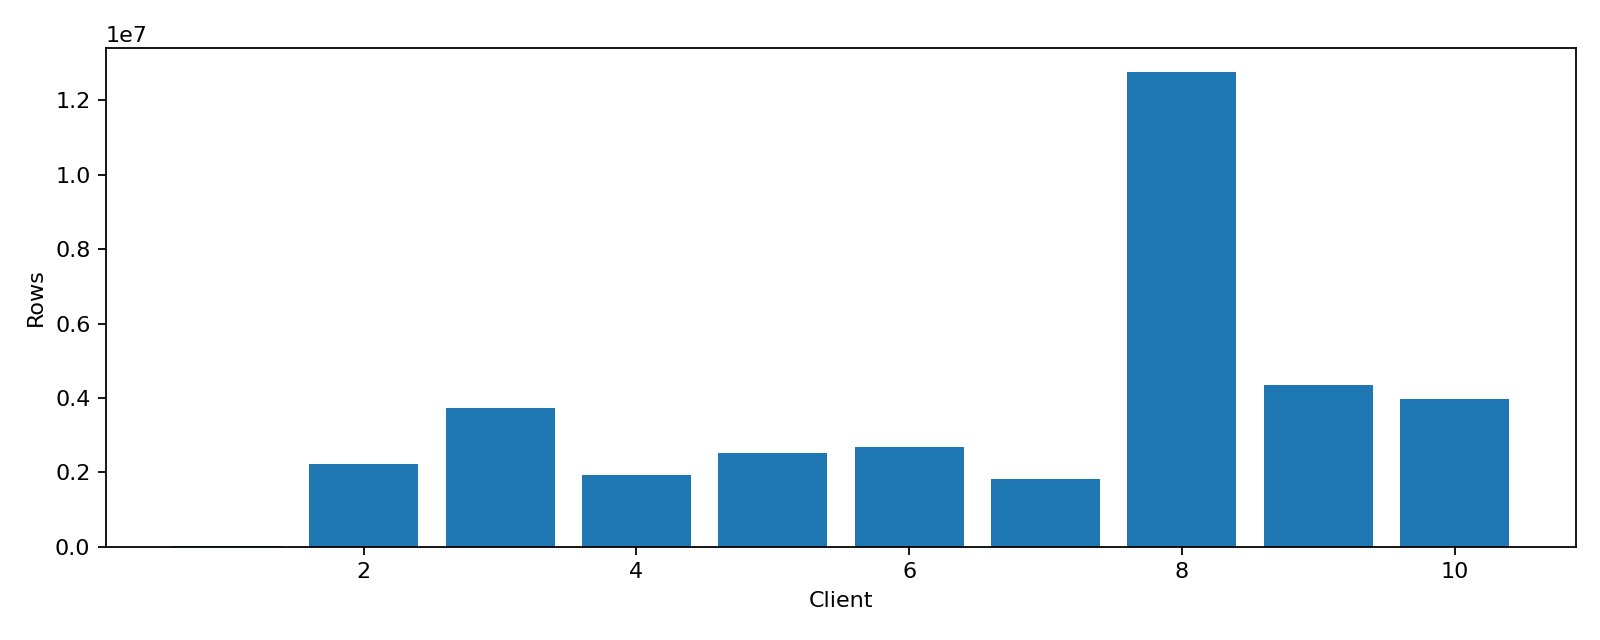

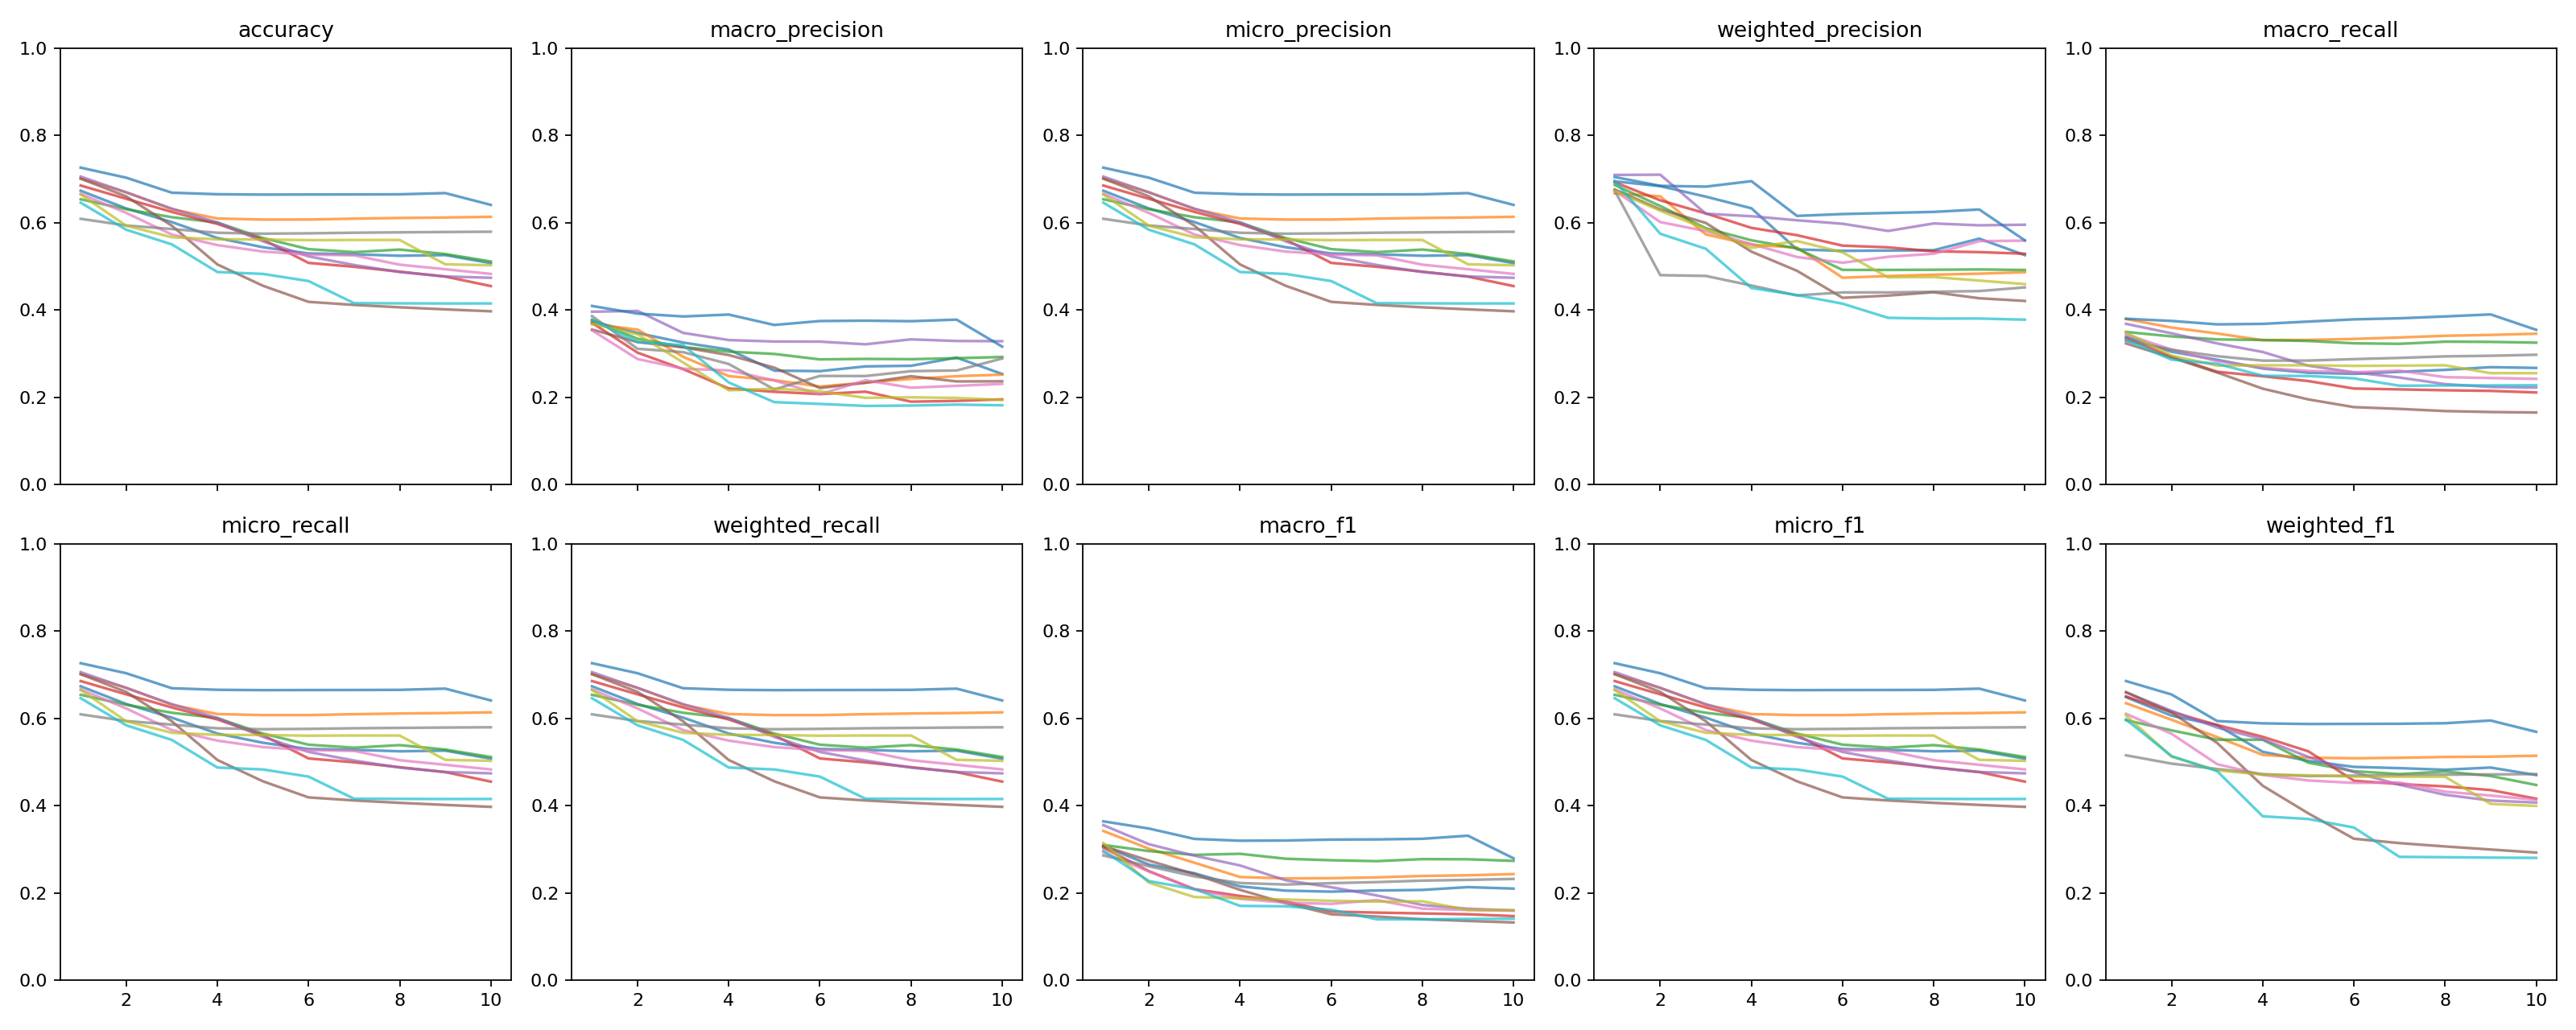

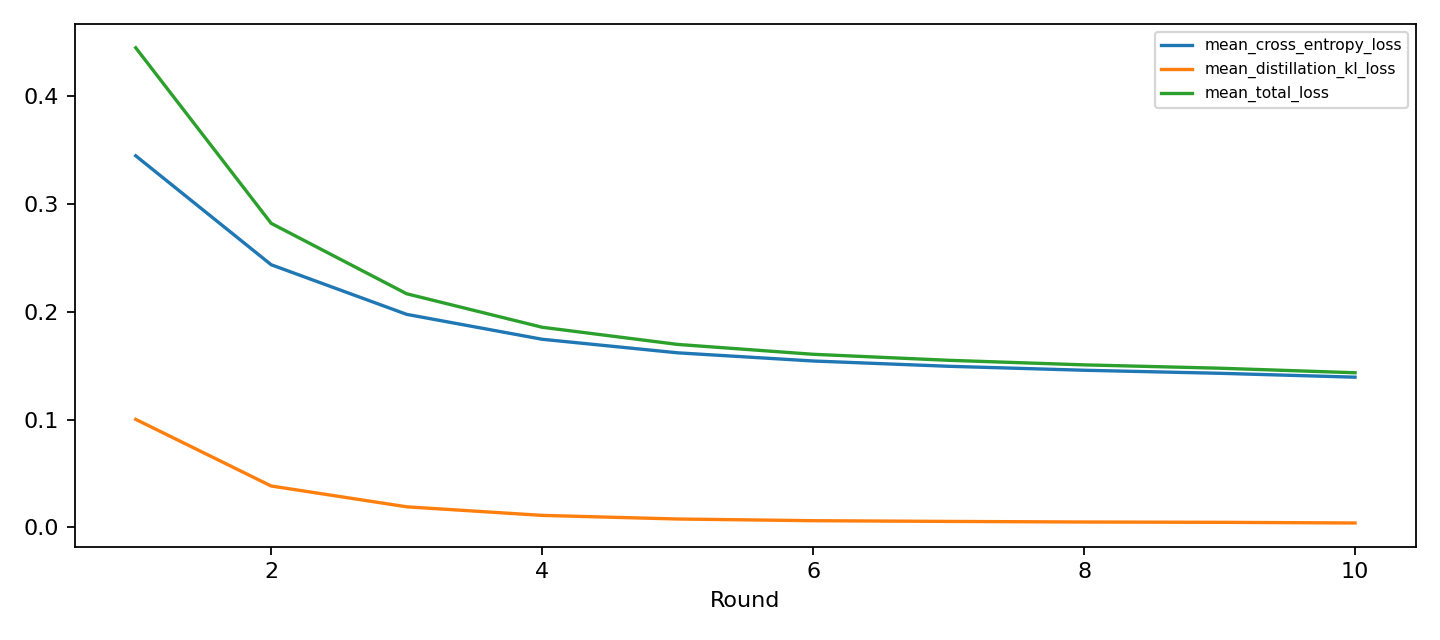

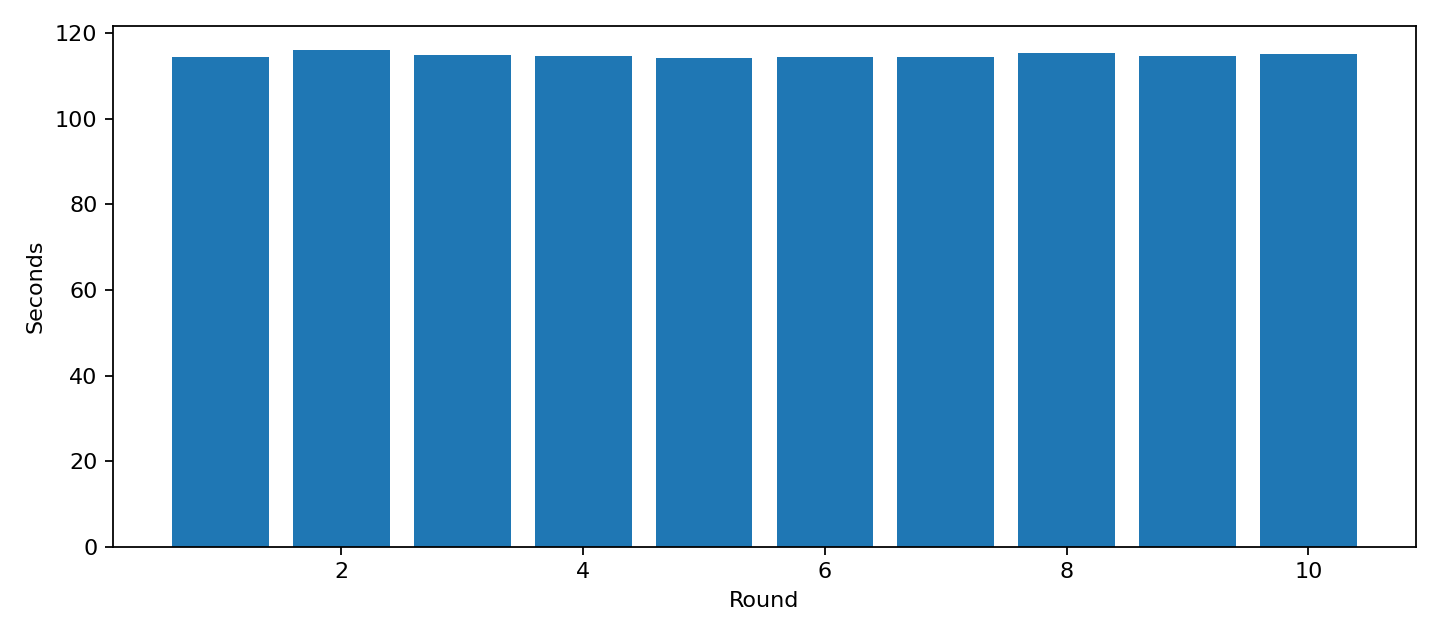

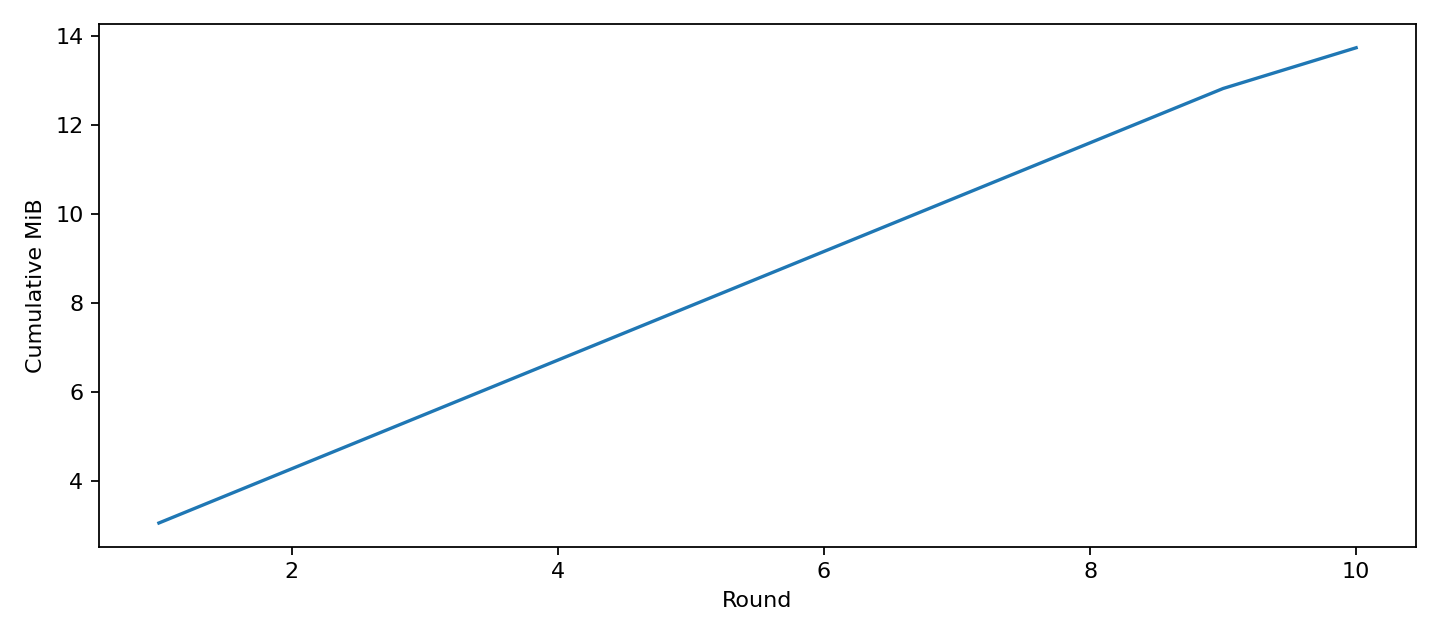

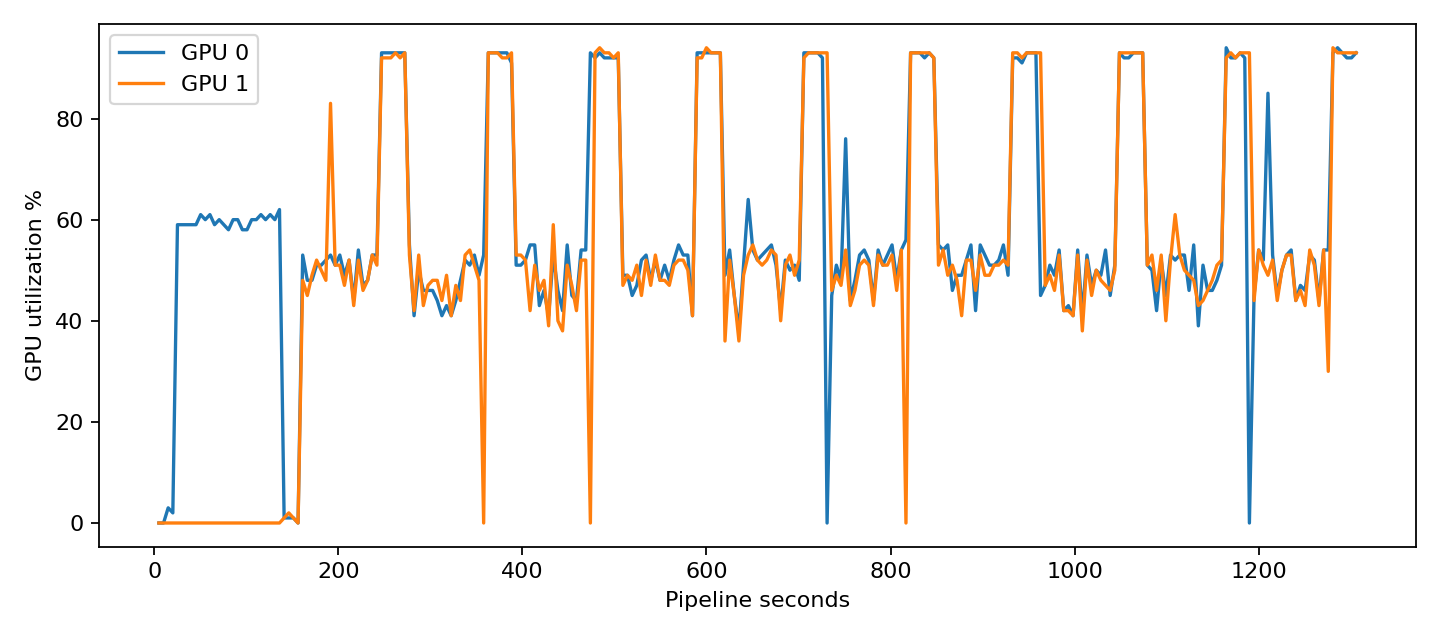

In [6]:
import pandas as pd
from IPython.display import display
from PIL import Image

output_dir = Path(CONFIG["output_dir"])
missing = []
for relative in EXPECTED_OUTPUTS:
    path = output_dir / relative
    if not path.exists() or (path.is_file() and path.stat().st_size == 0):
        missing.append(relative)
if missing:
    raise RuntimeError(f"Missing or empty outputs: {missing}")
metrics = pd.read_csv(output_dir / "metrics" / "evaluation_metrics.csv")
runtime.verify_evaluation_metrics(metrics.to_dict("records"), CONFIG, datasets["global_test"]["rows"])
checkpoint_manifest = json.loads((output_dir / "checkpoints" / "checkpoint_manifest.json").read_text(encoding="utf-8"))
runtime.verify_checkpoint_manifest(output_dir, CONFIG, checkpoint_manifest["entries"])
summary = json.loads((output_dir / "metrics" / "summary.json").read_text(encoding="utf-8"))
assert summary["status"] == "complete"
display(metrics.tail(20))
for filename in [
    "class_distribution.png",
    "evaluation_metric_curves.png",
    "loss_curves.png",
    "runtime_per_round.png",
    "communication_cumulative.png",
    "gpu_utilization.png",
]:
    display(Image.open(output_dir / "artifacts" / filename))
